# **MultiModal LLM With TGIF Connector**

In [ ]:
!pip uninstall -y transformers -q
!pip install -q datasets git+https://github.com/huggingface/transformers
!pip install -U bitsandbytes

!pip install pillow
!pip install -q gradio


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.4 MB/s eta 0:00:00


# **Stage 1- Pretraining**

Dataframe Shape: (78, 6)
   image_id filename                                              image  \
0         0    1.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1         1    2.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2         2    3.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3         3    4.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4         4    5.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
5         5    6.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
6         6    7.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
7         7    8.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
8         8    9.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
9         9   10.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                                text  \
0  Boy in red shirt holding a cricket bat upright...   
1  Boy in batting stance, bat raised 

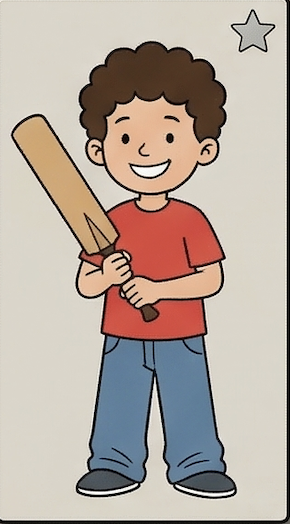

{0: 'Boy in red shirt holding a cricket bat upright, smiling.', 1: 'Boy in batting stance, bat raised behind shoulder, ready.'}
{0: ('Boy in red shirt holding a cricket bat upright, smiling.', 'How many bats and balls are in this image?', 'This image has 1 bat and no ball.'), 1: ('Boy in batting stance, bat raised behind shoulder, ready.', 'Where is the bat positioned in this batting stance?', "The bat is raised behind the boy's shoulder.")}
Boy in batting stance, bat raised behind shoulder, ready. 
 Where is the bat positioned in this batting stance?,
 The bat is raised behind the boy's shoulder.


In [ ]:
import pandas as pd
from datasets import Dataset
import io
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice

df = pd.read_parquet('cricket_vqa_bat_ball_count_1_78.parquet')

df['image_id'] = range(len(df))

# Display first few rows to å
print("Dataframe Shape:", df.shape)
print(df.head(10))

hf_dataset = Dataset.from_pandas(df.head(80))

image_bytes = hf_dataset[0]['image']['bytes']
image = Image.open(io.BytesIO(image_bytes))
# display(image)

from PIL import Image
import io
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice
import time

image_bytes = hf_dataset[0]['image']['bytes']

image = Image.open(io.BytesIO(image_bytes))
display(image)
instruct150k_caption = dict(zip(df['image_id'], df['text'].str.slice(0, 60)))

first_two_items = dict(islice(instruct150k_caption.items(), 2))
print(first_two_items)

instruct150k_qa = dict(zip(df['image_id'], zip(df['text'], df['question'], df['answer'])))

first_two_items = dict(islice(instruct150k_qa.items(), 2))
print(first_two_items)
instruct150k_images = dict(zip(df['image_id'], df['image']))

def get_image(image_id):
    return Image.open(io.BytesIO(instruct150k_images[image_id]['bytes']))


text, question, answer = instruct150k_qa[1]
print(f"{text} \n {question},\n {answer}")


In [ ]:
import os
import json
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DataCollatorWithPadding, AutoProcessor
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig

# Check if CUDA is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))  # Print GPU name
else:
    device = torch.device("cpu")
    print("Using CPU")


from huggingface_hub import login
from google.colab import userdata
access_token = userdata.get("hf")
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B",token=access_token)
llama = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B",token=access_token).to(device)

llama.model.embed_tokens
print(f'len(tokenizer 1: {len(tokenizer)}')

tokenizer.pad_token = tokenizer.eos_token
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id
eoi_string = 'caption image:'
eoi_tokens = tokenizer.encode(eoi_string)

print("check again", tokenizer.eos_token_id)
print(f'eoi_tokens : {eoi_tokens}')
print(bos_token_id, pad_token_id, eos_token_id)
print(tokenizer.decode([128000, 128001, 128001]))
print('eoi tokens decoded:', tokenizer.decode(eoi_tokens))
print(len(tokenizer))

vision_model_name = 'openai/clip-vit-base-patch32'

clip_patches = 49
clip_processor = CLIPImageProcessor.from_pretrained(vision_model_name)
clip_model = CLIPVisionModel.from_pretrained(vision_model_name).to(device)




Using GPU: Tesla T4


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

# **TGIF Router Code**

In [ ]:

# ============================================================
# TGIF: Text-Guided Inter-layer Fusion
# Replaces the static combine_features() from dense connector.
#
# Architecture (paper §3.1):
#   1. Extract hidden states from all L CLIP layers  → {F_l}  [B, 49, 768]
#   2. Pool LLM text embedding of the input query    → f_text  [B, D_t]
#   3. MLP router: f_text → z → softmax → w_layer    [B, L]
#   4. Fused feature: F_fused = Σ w_l · F_l          [B, 49, 768]
#   5. MLP connector projects F_fused → LLM space
#
# Key difference from dense connector:
#   Dense connector: static average of layers 1-12 CONCAT final layer → [B, 49, 1536]
#   TGIF           : text-guided weighted sum of layers 1-12          → [B, 49, 768]
# ============================================================


NUM_CLIP_LAYERS = 12       # CLIP ViT-base-patch32 has 12 transformer layers
CLIP_HIDDEN_DIM = 768      # hidden dim of each CLIP layer
LLM_HIDDEN_DIM  = 2048     # Llama-3.2-1B hidden dim (used for router input)


class TGIFRouter(nn.Module):
    """
    Lightweight MLP router (text-only variant, paper §3.1.1).
    Takes pooled LLM text embedding → per-layer softmax weights.

    z      = MLP(f_text)  ∈ R^L          (Eq. 1)
    w_layer = softmax(z)  ∈ R^L          (Eq. 2)
    """
    def __init__(self, text_dim=LLM_HIDDEN_DIM, num_layers=NUM_CLIP_LAYERS):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(text_dim, text_dim // 16),
            nn.GELU(),
            nn.Linear(text_dim // 16, num_layers),
        )

    def forward(self, f_text):
        # f_text: [B, text_dim]
        logits  = self.mlp(f_text)          # [B, num_layers]
        weights = F.softmax(logits, dim=-1) # [B, num_layers]
        return weights


def extract_layer_hidden_states(clip_output, select_layers=None):
    """
    Extract patch tokens (CLS removed) from each CLIP hidden-state layer.
    Returns: [B, num_layers, 49, CLIP_HIDDEN_DIM]

    Replaces combine_features() — instead of a static average+concat,
    we return raw per-layer tensors so TGIF can weight them dynamically.
    """
    if select_layers is None:
        select_layers = list(range(1, NUM_CLIP_LAYERS+1))  # layers 1..12
    feats = [clip_output.hidden_states[l][:, 1:, :] for l in select_layers]
    return torch.stack(feats, dim=1)  # [B, L, 49, 768]


def tgif_fuse_layers(layer_hidden_states, layer_weights):
    """
    Weighted sum of layer features (paper Eq. 3).
    F_fused = Σ_l  w_l · F_l

    layer_hidden_states : [B, L, 49, CLIP_HIDDEN_DIM]
    layer_weights       : [B, L]
    Returns             : [B, 49, CLIP_HIDDEN_DIM]

    # Uses bmm instead of broadcast-multiply to avoid materialising the full
    # [B, L, 49, D] intermediate tensor in VRAM during the backward pass.
    """
    B, L, P, D = layer_hidden_states.shape
    # [B, 1, L] x [B, L, P*D] → [B, 1, P*D] → [B, P, D]
    fused = torch.bmm(
        layer_weights.unsqueeze(1),                   # [B, 1, L]
        layer_hidden_states.view(B, L, P * D)         # [B, L, P*D]  (view = no copy)
    ).view(B, P, D)
    return fused

# ============================================================
# End of TGIF module definitions
# ============================================================

In [ ]:

# ============================================================
# TGIF: Text-Guided Inter-layer Fusion
# Replaces the static combine_features() from dense connector.
#
# Architecture (paper §3.1):
#   1. Extract hidden states from all L CLIP layers  → {F_l}  [B, 49, 768]
#   2. Pool LLM text embedding of the input query    → f_text  [B, D_t]
#   3. MLP router: f_text → z → softmax → w_layer    [B, L]
#   4. Fused feature: F_fused = Σ w_l · F_l          [B, 49, 768]
#   5. MLP connector projects F_fused → LLM space
#
# Key difference from dense connector:
#   Dense connector: static average of layers 1-12 CONCAT final layer → [B, 49, 1536]
#   TGIF           : text-guided weighted sum of layers 1-12          → [B, 49, 768]
# ============================================================


NUM_CLIP_LAYERS = 12       # CLIP ViT-base-patch32 has 12 transformer layers
CLIP_HIDDEN_DIM = 768      # hidden dim of each CLIP layer
LLM_HIDDEN_DIM  = 2048     # Llama-3.2-1B hidden dim (used for router input)


class TGIFRouter(nn.Module):
    def __init__(self, text_dim=LLM_HIDDEN_DIM, num_layers=NUM_CLIP_LAYERS):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(text_dim, text_dim // 16),
            nn.GELU(),
            nn.Linear(text_dim // 16, num_layers),
        )

    def forward(self, f_text):
        logits  = self.mlp(f_text)
        weights = F.softmax(logits, dim=-1)
        return weights


def extract_layer_hidden_states(clip_output, select_layers=None):
    if select_layers is None:
        select_layers = list(range(1, NUM_CLIP_LAYERS+1))
    feats = [clip_output.hidden_states[l][:, 1:, :] for l in select_layers]
    return torch.stack(feats, dim=1)


def tgif_fuse_layers(layer_hidden_states, layer_weights):
    B, L, P, D = layer_hidden_states.shape

    fused = torch.bmm(
        layer_weights.unsqueeze(1),
        layer_hidden_states.view(B, L, P * D)
    ).view(B, P, D)
    return fused

# ============================================================
# End of TGIF module definitions
# ============================================================

# **Agumentations and Caching**

In [ ]:
from torchvision import transforms
from tqdm import tqdm
from torchvision import transforms
from tqdm import tqdm

# Diversity pipeline (Hue shift fixes the color bias!)
aug_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])


def create_training_cache(hf_dataset, clip_model, clip_processor, num_variants=1):
    """
    Pre-compute and save CLIP layer hidden states for all training images.

    TGIF change vs dense connector:
      dense connector cached: clip_feat = [1, 49, 1536]  (static combined)
      TGIF          caches : clip_feat = [1, 12, 49, 768] (all layer hs)
    The TGIF router weights these layers at *training time* using the text query.
    """
    clip_model.eval()
    cache = []
    print("Pre-computing TGIF features (all layer hidden states)...")

    with torch.no_grad():
        for i in tqdm(range(len(hf_dataset))):
            img_id       = hf_dataset[i]['image_id']
            original_pil = get_image(img_id)
            caption      = instruct150k_caption[img_id]
            tokens = tokenizer(caption, truncation=True, padding='max_length',
                               max_length=20, return_tensors="pt")['input_ids']

            for variant_idx in range(num_variants):
                aug_img = original_pil
                inputs  = clip_processor(images=aug_img, return_tensors="pt").to(device)
                outputs = clip_model(**inputs, output_hidden_states=True)

                # TGIF: save per-layer hidden states instead of static combined features
                feat = extract_layer_hidden_states(outputs).detach().cpu()  # [1, 12, 49, 768]

                cache.append({
                    'image_id'      : img_id,
                    'clip_feat'     : feat,           # [1, L, 49, D]  ← TGIF format
                    'caption_tokens': tokens.squeeze(0),
                    'caption_text'  : caption
                })

    torch.save(cache, "augmented_cache_original_tgif.pt")
    print("TGIF cache saved to augmented_cache_original_tgif.pt")

# UNCOMMENT AND RUN ONCE:
create_training_cache(hf_dataset, clip_model, clip_processor)


def create_training_cache(hf_dataset, clip_model, clip_processor, num_variants=5):
    """
    Pre-compute and save CLIP layer hidden states for all training images.

    TGIF change vs dense connector:
      dense connector cached: clip_feat = [1, 49, 1536]  (static combined)
      TGIF          caches : clip_feat = [1, 12, 49, 768] (all layer hs)
    The TGIF router weights these layers at *training time* using the text query.
    """
    clip_model.eval()
    cache = []
    print("Pre-computing TGIF features (all layer hidden states)...")

    with torch.no_grad():
        for i in tqdm(range(len(hf_dataset))):
            img_id       = hf_dataset[i]['image_id']
            original_pil = get_image(img_id)
            caption      = instruct150k_caption[img_id]
            tokens = tokenizer(caption, truncation=True, padding='max_length',
                               max_length=20, return_tensors="pt")['input_ids']

            for variant_idx in range(num_variants):
                # Augment and run CLIP once
                aug_img = aug_pipeline(original_pil)
                inputs  = clip_processor(images=aug_img, return_tensors="pt").to(device)
                outputs = clip_model(**inputs, output_hidden_states=True)

                # TGIF: save per-layer hidden states instead of static combined features
                feat = extract_layer_hidden_states(outputs)  # [1, 12, 49, 768]

                cache.append({
                    'image_id'      : img_id,
                    'clip_feat'     : feat,           # [1, L, 49, D]  ← TGIF format
                    'caption_tokens': tokens.squeeze(0),
                    'caption_text'  : caption
                })

    torch.save(cache, "augmented_cache_tgif_variations.pt")
    print("TGIF cache saved to augmented_cache_tgif_variations.pt")


# UNCOMMENT AND RUN ONCE:
create_training_cache(hf_dataset, clip_model, clip_processor)

Pre-computing TGIF features (all layer hidden states)...


100%|██████████| 78/78 [00:02<00:00, 38.47it/s]


TGIF cache saved to augmented_cache_original_tgif.pt


# **Model Code**

In [ ]:
class ClipEmbeddingDataset(Dataset):
    """Unchanged — collate_fn handles any clip_feat shape via squeeze(0)+stack."""
    def __init__(self, cache_file):
        self.data = torch.load(cache_file, map_location='cpu')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def collate_fn(self, batch):
        return {
            # Works for both dense-connector [49,1536] and TGIF [12,49,768] shapes
            'clip_feats'    : torch.stack([item['clip_feat'].squeeze(0) for item in batch]),
            'caption_tokens': torch.stack([item['caption_tokens'] for item in batch]),
            'image_names'   : [item['image_id'] for item in batch],
            'captions'      : [item['caption_text'] for item in batch]
        }

class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        # print("x",x + self.proj(x))
        return x + self.proj(x)


# ============================================================
# TGIF Phi2ProjModel — Stage 1 (caption pre-training)
#
# Changes vs dense connector:
#   • Receives tgif_router as constructor argument
#   • clip_embed_dim = 768  (TGIF fuses to single-layer dim, not 1536)
#   • forward computes f_text = mean-pool LLM embed of target tokens,
#     routes CLIP layers via tgif_router, then fuses → clip_embeddings
#   • Stores self.last_layer_weights for the load-balancing loss
# ============================================================

class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama,
                 tgif_router,                    # TGIF: lightweight MLP router
                 clip_embed_dim=CLIP_HIDDEN_DIM, # TGIF: 768 (was 1536 in dense connector)
                 phi2_dim=LLM_HIDDEN_DIM):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim       = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)  # 768 → 2048
        self.clip_model     = clip_model
        self.clip_processor = clip_processor
        self.proj_model     = proj_model
        self.llama     = llama
        self.tgif_router    = tgif_router        # TGIF router
        self.last_layer_weights = None           # stored for load-balancing loss

    def forward(self, x, target_tokens, target_len, is_precomputed=False):
        if is_precomputed:
            # x is the TGIF cache tensor: [B, L, 49, 768]
            layer_hs = x.to(device=device, dtype=torch.float32).detach()
        else:
          with torch.no_grad():  # CLIP is frozen
            inputs      = self.clip_processor(images=x, return_tensors="pt").to(device)
            clip_output = self.clip_model(**inputs, output_hidden_states=True)
            layer_hs    = extract_layer_hidden_states(clip_output)   # [B, L, 49, 768]

        # TGIF: compute pooled text embedding for the router (Eq. 1-2)

        text_embeds = self.llama.model.embed_tokens(target_tokens)  # [B, T, 2048]
        f_text = text_embeds.mean(dim=1)                                     # [B, 2048]
        layer_weights = self.tgif_router(f_text)                             # [B, L]
        self.last_layer_weights = layer_weights   # stash for LB loss in training loop

        # TGIF: weighted fusion of CLIP layers (Eq. 3)
        clip_embeddings = tgif_fuse_layers(layer_hs, layer_weights)          # [B, 49, 768]

        image_embed = self.proj_lin_layer(clip_embeddings)   # [B, 49, 2048]
        image_embed = self.proj_model(image_embed)           # [B, 49, 2048]

        B, _, C = image_embed.shape
        eoi_tkn_tensor = torch.tensor(eoi_tokens, dtype=torch.int64).to(device)
        eoi_tensor     = eoi_tkn_tensor.repeat(B, 1)
        eoi_embed      = self.llama.model.embed_tokens(eoi_tensor)
        input_embed    = torch.cat([image_embed, eoi_embed], dim=1)

        pred_logits = []
        # Teacher-forcing autoregressive prediction loop (unchanged)
        for i in range(target_len):
            output            = self.llama.forward(inputs_embeds=input_embed)
            next_word_logit   = output.logits[:, -1, :].unsqueeze(1)
            pred_logits.append(next_word_logit)
            target_tkn        = target_tokens[:, i].view(B, 1)
            target_tkn_embed  = self.llama.model.embed_tokens(target_tkn)
            input_embed       = torch.cat([input_embed, target_tkn_embed], dim=1)

        return torch.cat(pred_logits, dim=1)

In [ ]:
class ClipEmbeddingDataset(Dataset):
    """Unchanged — collate_fn handles any clip_feat shape via squeeze(0)+stack."""
    def __init__(self, cache_file):
        self.data = torch.load(cache_file, map_location='cpu')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def collate_fn(self, batch):
        return {
            # Works for both dense-connector [49,1536] and TGIF [12,49,768] shapes
            'clip_feats'    : torch.stack([item['clip_feat'].squeeze(0) for item in batch]),
            'caption_tokens': torch.stack([item['caption_tokens'] for item in batch]),
            'image_names'   : [item['image_id'] for item in batch],
            'captions'      : [item['caption_text'] for item in batch]
        }

class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        # print("x",x + self.proj(x))
        return x + self.proj(x)


# ============================================================
# TGIF Phi2ProjModel — Stage 1 (caption pre-training)
#
# Changes vs dense connector:
#   • Receives tgif_router as constructor argument
#   • clip_embed_dim = 768  (TGIF fuses to single-layer dim, not 1536)
#   • forward computes f_text = mean-pool LLM embed of target tokens,
#     routes CLIP layers via tgif_router, then fuses → clip_embeddings
#   • Stores self.last_layer_weights for the load-balancing loss
# ============================================================

class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama,
                 tgif_router,                    # TGIF: lightweight MLP router
                 clip_embed_dim=CLIP_HIDDEN_DIM, # TGIF: 768 (was 1536 in dense connector)
                 phi2_dim=LLM_HIDDEN_DIM):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim       = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)  # 768 → 2048
        self.clip_model     = clip_model
        self.clip_processor = clip_processor
        self.proj_model     = proj_model
        self.llama     = llama
        self.tgif_router    = tgif_router        # TGIF router
        self.last_layer_weights = None           # stored for load-balancing loss

    def forward(self, x, target_tokens, target_len, is_precomputed=False):
        if is_precomputed:
            layer_hs = x.to(device=device, dtype=torch.float32).detach()
        else:
          with torch.no_grad():  # CLIP is frozen
            inputs      = self.clip_processor(images=x, return_tensors="pt").to(device)
            clip_output = self.clip_model(**inputs, output_hidden_states=True)
            layer_hs    = extract_layer_hidden_states(clip_output)

        text_embeds = self.llama.model.embed_tokens(target_tokens)
        f_text = text_embeds.mean(dim=1)
        layer_weights = self.tgif_router(f_text)
        self.last_layer_weights = layer_weights   # stash for LB loss in training loop

        # TGIF: weighted fusion of CLIP layers (Eq. 3)
        clip_embeddings = tgif_fuse_layers(layer_hs, layer_weights)

        image_embed = self.proj_lin_layer(clip_embeddings)
        image_embed = self.proj_model(image_embed)

        B, _, C = image_embed.shape
        eoi_tkn_tensor = torch.tensor(eoi_tokens, dtype=torch.int64).to(device)
        eoi_tensor     = eoi_tkn_tensor.repeat(B, 1)
        eoi_embed      = self.llama.model.embed_tokens(eoi_tensor)
        input_embed    = torch.cat([image_embed, eoi_embed], dim=1)

        pred_logits = []
        # Teacher-forcing autoregressive prediction loop (unchanged)
        for i in range(target_len):
            output            = self.llama.forward(inputs_embeds=input_embed)
            next_word_logit   = output.logits[:, -1, :].unsqueeze(1)
            pred_logits.append(next_word_logit)
            target_tkn        = target_tokens[:, i].view(B, 1)
            target_tkn_embed  = self.llama.model.embed_tokens(target_tkn)
            input_embed       = torch.cat([input_embed, target_tkn_embed], dim=1)

        return torch.cat(pred_logits, dim=1)

In [ ]:
import gc, torch
try:
    del model, optimizer, batch  # replace with your names
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import torch

# Load the cached data files
import torch

# Load the cached data files
cached_data_main       = torch.load("augmented_cache_original_tgif.pt")
cached_data_variations = torch.load("augmented_cache_tgif_variations.pt")

# Merge the two lists of data
cached_data = cached_data_main + cached_data_variations

# Print the number of objects in the merged cache
print(f"Number of objects in merged cached_data: {len(cached_data)}")



def get_embedding_by_image_id(image_id):
    """Retrieves the CLIP embedding for a given image_id from the cached data."""
    for item in cached_data:
        if item['image_id'] == image_id:
            return item['clip_feat']
    return None

torch.save(cached_data, "merged_cache_layer_multi_tgif.pt")
print("Merged cache saved to merged_cache_multi_layer.pt")

Number of objects in merged cached_data: 468
Merged cache saved to merged_cache_multi_layer.pt


In [ ]:
cached_data_testing_n = torch.load("merged_cache_layer_multi_tgif.pt")

print(len(cached_data_testing_n))

468


In [ ]:
import torch

dataset = ClipEmbeddingDataset("augmented_cache_original_tgif.pt")
batch_size = 2
dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=dataset.collate_fn, shuffle=True)


for idx, batch in enumerate(dataloader):
    image_names = batch['image_names']  # List of image names corresponding to each data slice
    captions = batch['captions']  # List of captions corresponding to each data slice
    caption_tokens = batch['caption_tokens']  # Shape: [batch_size, max_seq_len]
    clip_feats = batch['clip_feats']
    print(idx)
    print(image_names)
    print(captions)
    print(caption_tokens.shape, caption_tokens)
    print(clip_feats.shape)
    print('---------')
    if idx > 0:
        break



tgif_router     = TGIFRouter(text_dim=LLM_HIDDEN_DIM, num_layers=NUM_CLIP_LAYERS).to(device)
projection_layer = ClipProjectionBlock(LLM_HIDDEN_DIM).to(device)
phi2_proj_model = Phi2ProjModel(
    clip_model, clip_processor, projection_layer, llama,
    tgif_router                  # TGIF router passed here
).to(device).float()

# TGIF NOTE: proj_lin_layer input changed 1536→768; load only if TGIF checkpoint exists.
phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phiproj_ll_load.pth'))
phi2_proj_model.proj_model.load_state_dict(torch.load('phiproj_projm_load.pth'))   # compatible
phi2_proj_model.tgif_router.load_state_dict(torch.load('tgif_router_load.pth'))  # if resuming

grad_wt_count = 0
non_grad_wt_count = 0
for name, param in phi2_proj_model.named_parameters():
    if "proj_model" in name:
        param.requires_grad = True
        print(name)
        print("proj_model")
        grad_wt_count += 1
    elif "proj_lin_layer" in name:
        print(name)
        param.requires_grad = True
        print("proj_lin_layer")
        grad_wt_count += 1
    elif "tgif_router" in name:
        print(name)
        param.requires_grad = True
        print("tgif_router")
        grad_wt_count += 1
    else:
        param.requires_grad = False
        non_grad_wt_count += 1
print(f'Parms with grad : {grad_wt_count} & Parms w/o grad : {non_grad_wt_count}')
# optimizer = torch.optim.AdamW(projection_layer.parameters(), lr=1e-3)
# optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, phi2_proj_model.parameters()), lr=1e-5, eps=1e-9)


# Sanity-check: verify router params are trainable before creating optimizer
for name, param in phi2_proj_model.tgif_router.named_parameters():
    assert param.requires_grad, f"tgif_router.{name} requires_grad is False — load_state_dict reset it!"
print("✓ tgif_router params confirmed requires_grad=True")

optimizer = torch.optim.Adam([
    {'params': phi2_proj_model.proj_lin_layer.parameters(), 'lr': 1e-5},
    {'params': phi2_proj_model.proj_model.parameters(),     'lr': 1e-5},
    {'params': phi2_proj_model.tgif_router.parameters(),    'lr': 1e-4},  # ← Routers are small
], eps=1e-9)

0
[44, 15]
['Rear view, boy with bat on shoulder, balls on ground.', 'Boy holding bat diagonally across front of his body.']
torch.Size([2, 20]) tensor([[128000,     49,    686,   1684,     11,   8334,    449,  16120,    389,
          17308,     11,  20953,    389,   5015,     13, 128001, 128001, 128001,
         128001, 128001],
        [128000,  63504,  10168,  16120,  85118,    750,   4028,   4156,    315,
            813,   2547,     13, 128001, 128001, 128001, 128001, 128001, 128001,
         128001, 128001]])
torch.Size([2, 12, 49, 768])
---------
1
[40, 51]
['Close-up of one hand gripping top of bat handle.', 'Close-up of bat striking ball, motion blur lines.']
torch.Size([2, 20]) tensor([[128000,   8084,   5352,    315,    832,   1450,  81291,   1948,    315,
          16120,   3790,     13, 128001, 128001, 128001, 128001, 128001, 128001,
         128001, 128001],
        [128000,   8084,   5352,    315,  16120,  21933,   5041,     11,  11633,
          29613,   5238,     13, 

# **Training**

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# Setup Dataloader with Cache
# ============================================================
# Stage 1 Training Loop with TGIF Load-Balancing Loss (paper §3.2)
#
# L_total = L_CE  +  λ · Σ_l  w̄_l · log(w̄_l + ε)
# where w̄ = mean over batch of per-sample router weights.
# λ = 0.01 (pretraining, paper recommends slightly larger during Stage 1)
# ============================================================

from torch.distributions import Categorical

LAMBDA_LB_PRETRAIN = 0.005   # load-balancing coefficient for Stage 1 (paper §4.7.2)

def run_train():
    phi2_proj_model.train()
    diagnostic_batch = 0
    for idx, batch in enumerate(dataloader):
        clip_feats    = batch['clip_feats'].to(device)      # [B, 12, 49, 768]
        target_tokens = batch['caption_tokens'].to(device)
        T_            = target_tokens.shape[1]

        pred_logits = phi2_proj_model(clip_feats, target_tokens, T_, is_precomputed=True)

        B, T, C = pred_logits.shape
        ce_loss = F.cross_entropy(pred_logits.view(-1, C), target_tokens.view(-1))

        # TGIF load-balancing loss — entropy over mean per-layer weights (Eq. 5-6)
        # H = -Σ(w·log w) > 0  (entropy, maximised when routing is uniform)
        # To MAXIMISE H we MINIMISE -H, so lb_loss = +Σ(w·log w)  (a negative scalar)
        # total_loss = ce_loss + lb_loss = ce_loss - λ·H
        # Minimising total_loss drives H upward → diverse routing, prevents collapse.
        # (Previous sign was inverted: -λ·Σ(w·log w) = +λ·H, which *minimised* entropy.)

        layer_weights = phi2_proj_model.last_layer_weights          # [B, L]
        w_bar         = layer_weights.mean(dim=0)                   # [L]
         # Debug: track entropy evolution
        entropy       = -(w_bar * torch.log(w_bar + 1e-8)).sum().item()
        #lb_loss       = -LAMBDA_LB_PRETRAIN * (w_bar * torch.log(w_bar + 1e-8)).sum()
        lb_loss       = LAMBDA_LB_PRETRAIN * (w_bar * torch.log(w_bar + 1e-8)).sum()  # -λ·H
        loss          = ce_loss + lb_loss

        loss.backward()


        # ===== DIAGNOSTIC: Check router gradients (first batch only) =====
        if diagnostic_batch == 0:
            print("\n" + "="*80)
            print("DIAGNOSTIC: Router Gradient Check")
            print("="*80)
            router_has_grad = False
            for name, param in phi2_proj_model.tgif_router.named_parameters():
                if param.grad is not None:
                    grad_norm = param.grad.norm().item()
                    print(f"  {name}: grad_norm = {grad_norm:.2e}")
                    if grad_norm > 0:
                        router_has_grad = True
                else:
                    print(f"  {name}: grad = NONE ⚠️")

            if not router_has_grad:
                print("\n❌ CRITICAL: Router has ZERO gradients!")
                print("   → Loss does NOT depend on router weights")
                print("   → Fusion layer is likely DETACHED")
                print("   → Check tgif_fuse_layers() for detach() calls")
            else:
                print("\n✓ Router IS receiving gradients")

            # Also check if layer_weights are connected to loss
            print(f"\nlayer_weights requires_grad: {layer_weights.requires_grad}")
            print(f"layer_weights grad: {layer_weights.grad}")
            print("="*80 + "\n")
            diagnostic_batch += 1

        optimizer.step()
        optimizer.zero_grad()
        torch.cuda.empty_cache()

        print(f'idx: {idx}, loss: {loss:.4f}  ce: {ce_loss:.4f}  lb: {lb_loss:.6f}  tgt-len: {T_}')

        if idx % 5 == 0:  # print every 5 batches
            print(f'idx: {idx}, loss: {loss:.4f}  ce: {ce_loss:.4f} lb: {lb_loss:.6f} tgt-len: {T_} entropy: {entropy:.4f} '
                  f'w_bar_max: {w_bar.max():.4f}  w_bar_min: {w_bar.min():.4f}')

        preds      = F.softmax(pred_logits, dim=-1).to(torch.float32)
        display_ids = Categorical(probs=preds).sample()
        out_text   = tokenizer.batch_decode(display_ids)
        print(f'idx : {idx}')
        print(f"pred: {out_text[0]}")
        print(f"GT: {batch['captions'][0]}")

        if idx % 10 == 0:
            print(f'Batch: {idx}, Loss: {loss.item():.4f}')


for epoch in range(3):
    run_train()
    print(str(epoch))
    time.sleep(10)
    # Save Stage 1 weights
    torch.save(phi2_proj_model.proj_lin_layer.state_dict(), 'phiproj_ll.pth')
    torch.save(phi2_proj_model.proj_model.state_dict(),     'phiproj_projm.pth')
    torch.save(phi2_proj_model.tgif_router.state_dict(),    'tgif_router.pth')   # TGIF


DIAGNOSTIC: Router Gradient Check
  mlp.0.weight: grad_norm = 4.39e-03
  mlp.0.bias: grad_norm = 1.05e-02
  mlp.2.weight: grad_norm = 3.45e-02
  mlp.2.bias: grad_norm = 2.81e-02

✓ Router IS receiving gradients

layer_weights requires_grad: True
layer_weights grad: None



/tmp/ipykernel_2276/2177781052.py:70: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  print(f"layer_weights grad: {layer_weights.grad}")


idx: 0, loss: 0.4349  ce: 0.4470  lb: -0.012059  tgt-len: 20
idx: 0, loss: 0.4349  ce: 0.4470 lb: -0.012059 tgt-len: 20 entropy: 2.4119 w_bar_max: 0.1539  w_bar_min: 0.0496
idx : 0
pred: <|begin_of_text|>Home-quarter front view, boy in relaxed walking stance.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>
GT: Three-quarter front view, boy in relaxed walking pose.
Batch: 0, Loss: 0.4349
idx: 1, loss: 0.4654  ce: 0.4775  lb: -0.012053  tgt-len: 20
idx : 1
pred: <|begin_of_text|>Tags standing, arm relaxed at sides, no equipment.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>
GT: Boy standing, arms relaxed at sides, no equipment.
idx: 2, loss: 0.4587  ce: 0.4707  lb: -0.011991  tgt-len: 20
idx : 2
pred: 余“It standing calmly, neutral expression, no equipment.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>

In [ ]:
# ---- Quick text-embed check (unchanged) ----
text_tokens    = tokenizer.encode(text)
text_tkn_tensor = torch.tensor(text_tokens, dtype=torch.int64).to(device)
text_tkn_tensor = text_tkn_tensor.unsqueeze(0)
text_embed     = phi2_proj_model.llama.model.embed_tokens(text_tkn_tensor)
print("text embd", text_embed)
text_embed.shape

text embd tensor([[[ 0.0028,  0.0033, -0.0099,  ..., -0.0018,  0.0008,  0.0007],
         [-0.0065,  0.0231, -0.0104,  ...,  0.0058, -0.0060,  0.0327],
         [ 0.0248,  0.0074, -0.0596,  ...,  0.0297,  0.0205, -0.0045],
         ...,
         [ 0.0035, -0.0337,  0.0488,  ..., -0.0140, -0.0154, -0.0349],
         [ 0.0198,  0.0002, -0.0277,  ..., -0.0077, -0.0078, -0.0359],
         [-0.0101, -0.0261,  0.0295,  ..., -0.0256, -0.0178,  0.0062]]],
       device='cuda:0')


torch.Size([1, 14, 2048])

# **After Stage 1 Pretraining - Model Inference Check:**

In [ ]:

# ============================================================
# Stage 1 Inference Model
# ============================================================

class Phi2ProjModelPred(nn.Module):
    """
    Wraps the trained Stage-1 components for generation.
    TGIF change: receives tgif_router; clip_embed_dim=768.
    """
    def __init__(self, clip_model, clip_processor, proj_model, llama,
                 tgif_router,
                 clip_embed_dim=CLIP_HIDDEN_DIM,
                 phi2_dim=LLM_HIDDEN_DIM):
        super(Phi2ProjModelPred, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim       = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)
        self.clip_model     = clip_model
        self.clip_processor = clip_processor
        self.proj_model     = proj_model
        self.llama     = llama
        self.tgif_router    = tgif_router   # TGIF router for inference routing

    def forward(self, input_embed):
        max_len = 50
        output  = self.llama.generate(
            inputs_embeds=input_embed,
            max_new_tokens=max_len,
            return_dict_in_generate=True,
            bos_token_id=bos_token_id,
            pad_token_id=pad_token_id,
            eos_token_id=eos_token_id
        )
        return output


phi2_proj_model_pred = Phi2ProjModelPred(
    phi2_proj_model.clip_model,
    phi2_proj_model.clip_processor,
    phi2_proj_model.proj_model,
    phi2_proj_model.llama,
    phi2_proj_model.tgif_router      # share the trained TGIF router
).to(device).float()

# TGIF NOTE: proj_lin_layer 1536→768; load TGIF checkpoint here if available.
phi2_proj_model_pred.proj_lin_layer.load_state_dict(torch.load('phiproj_ll.pth'))
phi2_proj_model_pred.proj_model.load_state_dict(torch.load('phiproj_projm.pth'))
phi2_proj_model_pred.tgif_router.load_state_dict(torch.load('tgif_router.pth'))


eos_token_id = tokenizer.eos_token_id
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
phi2_proj_model_pred.eval()
clip_model.eval()

CLIPVisionModel(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (position_embedding): Embedding(50, 768)
  )
  (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
    

In [ ]:

def get_inference_features(img, n_augments=10):
    """
    Augmented-average TGIF features.
    Returns: averaged layer hidden states [1, L, 49, 768]
    (Replaces dense connector's combined [1, 49, 1536])
    """
    clip_model.eval()
    all_layer_hs = []
    with torch.no_grad():
        for _ in range(n_augments):
            aug_img  = img
            inputs   = clip_processor(images=aug_img, return_tensors="pt").to(device)
            outputs  = clip_model(**inputs, output_hidden_states=True)
            layer_hs = extract_layer_hidden_states(outputs)   # [1, L, 49, 768]
            all_layer_hs.append(layer_hs)
    # Average across augmentations: [n, 1, L, 49, 768] → mean → [1, L, 49, 768]
    return torch.stack(all_layer_hs).mean(dim=0)




def prepare_image_input_embed(img=None, text=None, extra=None):
    """
    Build the final input embedding for Stage-1 inference.

    TGIF change:
      1. get_inference_features returns averaged layer hidden states [1, L, 49, 768]
      2. Pool LLM embedding of the text query → f_text [1, 2048]
      3. Route CLIP layers via tgif_router → layer_weights [1, L]
      4. Fuse → clip_embeddings [1, 49, 768]
    """
    audio             = None
    input_embed_exists = 0
    inputs_given      = []

    if img is not None:
        # TGIF step 1: get averaged layer hidden states
        layer_hs = get_inference_features(img)       # [1, L, 49, 768]

        # TGIF step 2: pool LLM text embedding for router
        if text is not None:
            text_tkn = torch.tensor(text, dtype=torch.int64).to(device).unsqueeze(0)
            with torch.no_grad():
                t_emb  = phi2_proj_model_pred.llama.model.embed_tokens(text_tkn)
            f_text = t_emb.mean(dim=1)   # [1, 2048]
        else:
            f_text = torch.zeros(1, LLM_HIDDEN_DIM, device=device)

        # TGIF step 3-4: route + fuse
        layer_weights   = phi2_proj_model_pred.tgif_router(f_text)        # [1, L]
        clip_embeddings = tgif_fuse_layers(layer_hs, layer_weights)       # [1, 49, 768]

        image_embed = phi2_proj_model_pred.proj_lin_layer(clip_embeddings)   # [1, 49, 2048]
        image_embed = phi2_proj_model_pred.proj_model(image_embed)           # [1, 49, 2048]
        B, _, C     = image_embed.shape
        eoi_tkn_tensor  = torch.tensor(eoi_tokens, dtype=torch.int64).to(device)
        eoi_tensor      = eoi_tkn_tensor.repeat(B, 1)
        eoi_embed       = phi2_proj_model_pred.llama.model.embed_tokens(eoi_tensor)
        input_image_embed = torch.cat([image_embed, eoi_embed], dim=1)
        print("image embd", input_image_embed)

    if text is not None:
        text_tkn_tensor = torch.tensor(text, dtype=torch.int64).to(device)
        text_tkn_tensor = text_tkn_tensor.unsqueeze(0)
        text_embed_seq  = phi2_proj_model.llama.model.embed_tokens(text_tkn_tensor)
        print("text embd", text_embed_seq)

    if img is not None:
        input_embed       = input_image_embed
        input_embed_exists = 1

    if text:
        if input_embed_exists:
            input_embed = torch.cat([input_embed, text_embed_seq], dim=1)
        else:
            input_embed       = text_embed_seq
            input_embed_exists = 1
        inputs_given.append(text)

    print(f"Question Text: {tokenizer.decode(text)}")
    print("\n--- Full Combined String ---")
    full_string = tokenizer.decode(eoi_tokens) + tokenizer.decode(text)
    print(full_string)
    print("final input embd", input_embed)

    return input_embed.to(phi2_proj_model.llama.dtype)

In [ ]:

def gradio_get_caption_image_fn1(image=None, audio=None, text=None):
    audio_tokens  = None
    text_tokens   = None

    text = "Close-up of hands gripping bat, arrow at"
    print("text is", text)
    if text:
        text_tokens = tokenizer.encode(text)
        print("text_input", tokenizer.decode(text_tokens))

    if image:
        input_embed = prepare_image_input_embed(image, text_tokens)
        with torch.no_grad():
            output   = phi2_proj_model_pred(input_embed)
            print("seq", output.sequences)
            out_text = tokenizer.batch_decode(output.sequences)[0]
            print(out_text)
    else:
        out_text = "I didn't get any input. Give me an image/audio/text or combination of these 3 and get the answer back !"

    return out_text


import gradio as gr

markdown_description = """
Multimodal llm with image question capabilities
"""
demo = gr.Interface(
    fn=gradio_get_caption_image_fn1,
    inputs=[gr.Image(type="pil", label="Image")],
    outputs=gr.Textbox(label="Response"),
    title="Image Caption is",
    description=markdown_description,
    article="tp"
)
demo.queue().launch(share=True, debug=True)

# **Stage 2 - Finetuning VQA**

Using GPU: Tesla T4
Dataframe Shape: (78, 6)
   image_id filename                                              image  \
0         0    1.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1         1    2.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2         2    3.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3         3    4.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4         4    5.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
5         5    6.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
6         6    7.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
7         7    8.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
8         8    9.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
9         9   10.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                                text  \
0  Boy in red shirt holding a cricket bat upright...   
1  Boy in batting

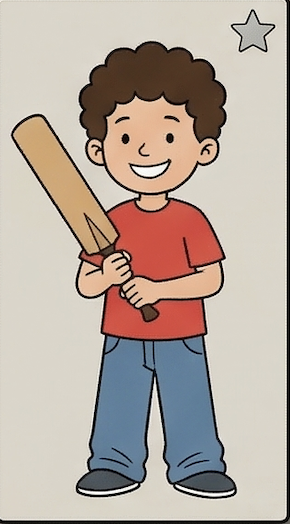

{0: 'Boy in red shirt holding a cricket bat upright, smiling.', 1: 'Boy in batting stance, bat raised behind shoulder, ready.'}
{0: ('Boy in red shirt holding a cricket bat upright, smiling.', 'What is the boy holding in this image?', 'He is holding a wooden cricket bat with both hands.'), 1: ('Boy in batting stance, bat raised behind shoulder, ready.', 'What batting action is the boy preparing?', 'He is raising the bat behind his shoulder to swing.')}
468
Boy in red shirt holding a cricket bat upright, smiling. 
 What is the boy holding in this image?,
 He is holding a wooden cricket bat with both hands.


In [ ]:
import os
import json
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DataCollatorWithPadding, AutoProcessor
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig
import peft
from peft import LoraConfig

# Check if CUDA is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))  # Print GPU name
else:
    device = torch.device("cpu")
    print("Using CPU")


import pandas as pd
from datasets import Dataset
import io
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice

# Load the Parquet file
# df = pd.read_parquet('train_data_image_10.parquet')
df = pd.read_parquet('cricket_vqa_dataset_1_78.parquet')
df1 = pd.read_parquet('cricket_vqa_bat_ball_count_1_78.parquet')
df2 = pd.read_parquet('cricket_vqa_tgif_typed_1_78.parquet')

df3 = pd.read_parquet('cricket_vqa_tgif_typed_3_78_diverse.parquet')
df4 = pd.read_parquet('cricket_vqa_counting_78.parquet')
df5 = pd.read_parquet('cricket_vqa_counting_with_different_questions_78.parquet')


# Fix image_id to be in proper sequence (0, 1, 2, ...) for df
df['image_id'] = range(len(df))

# Adjust image_id for df1, df2, df3, df4, and df5 to ensure uniqueness after concatenation
# df has image_ids 0 to len(df)-1.
current_max_id = len(df)
df1['image_id'] = range(current_max_id, current_max_id + len(df1))
current_max_id += len(df1)
df2['image_id'] = range(current_max_id, current_max_id + len(df2))
current_max_id += len(df2)
df3['image_id'] = range(current_max_id, current_max_id + len(df3))
current_max_id += len(df3)
df4['image_id'] = range(current_max_id, current_max_id + len(df4))
current_max_id += len(df4)
df5['image_id'] = range(current_max_id, current_max_id + len(df5))


# Display first few rows to å
print("Dataframe Shape:", df.shape)
print(df.head(10))

# Combine them. ignore_index=True gives you a fresh index from 0 to 155
df_combined = pd.concat([df, df1, df2, df3, df4, df5], ignore_index=True)

# # Adjust index to be from 1 to 156
# df_combined.index = df_combined.index + 1

# Re-create the HF dataset with the updated dataframe
hf_dataset = Dataset.from_pandas(df_combined)

# Example of accessing an image from the fixed dataset
# image_bytes = hf_dataset[0]['image']['bytes']
# image = Image.Image.open(io.BytesIO(image_bytes))
# display(image)


from PIL import Image
import io
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice
import time
from torch.utils.data import Dataset, DataLoader

image_bytes = hf_dataset[0]['image']['bytes']

image = Image.open(io.BytesIO(image_bytes))
display(image)

# Use df_combined's unique image_id as keys for all mappings
instruct150k_caption = dict(zip(df_combined['image_id'], df_combined['text'].str.slice(0, 60)))

first_two_items = dict(islice(instruct150k_caption.items(), 2))
print(first_two_items)

instruct150k_qa = dict(zip(df_combined['image_id'], zip(df_combined['text'], df_combined['question'], df_combined['answer'])))
first_two_items = dict(islice(instruct150k_qa.items(), 2))
print(first_two_items)

# Store all images, indexed by their unique image_id
instruct150k_images = dict(zip(df_combined['image_id'], df_combined['image']))

print(len(instruct150k_qa))

# The virtual_to_physical_map is no longer needed as image_id is now unique and direct.
# Removed virtual_to_physical_map.

def get_image(image_id):
    # Retrieve the image data directly using the (now unique) image_id
    # The previous hardcoded '234' and '233' logic is removed to dynamically handle any image_id
    if image_id in instruct150k_images:
        return Image.open(io.BytesIO(instruct150k_images[image_id]['bytes']))
    else:
        # Fallback for out-of-bounds IDs or other issues, or raise an error
        print(f"Warning: Image ID {image_id} not found in instruct150k_images. Returning a default or handling error.")
        # You might want to return a blank image, a placeholder, or raise an error
        return Image.new('RGB', (224, 224), color = 'red') # Placeholder red image


text, question, answer = instruct150k_qa[0] # Testing with a lower index, assuming 0 is always valid now
print(f"{text} \n {question},\n {answer}")

In [ ]:
print(instruct150k_qa)

{0: ('Boy in red shirt holding a cricket bat upright, smiling.', 'What is the boy holding in this image?', 'He is holding a wooden cricket bat with both hands.'), 1: ('Boy in batting stance, bat raised behind shoulder, ready.', 'What batting action is the boy preparing?', 'He is raising the bat behind his shoulder to swing.'), 2: ('Boy resting cricket bat over right shoulder, relaxed pose.', 'How is the boy carrying the cricket bat?', 'Bat rested over his right shoulder in a relaxed pose.'), 3: ('Boy holding a tree branch, angry face, X icon shown.', 'Is the object the boy holds a cricket bat?', 'No, he holds a tree branch. The X icon confirms error.'), 4: ('Boy holding a straw broom, question mark icon shown.', 'What is unusual about the object he holds?', 'He holds a broom instead of a bat; question mark shown.'), 5: ('Boy holding a wooden plank, two question marks floating.', 'What is the boy holding and why is it wrong?', 'A wooden plank, not a bat; question marks show confusion.')

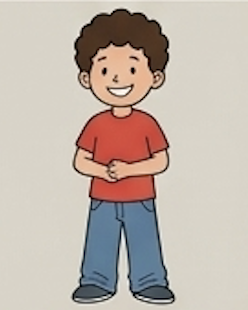

In [ ]:
get_image(135)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B",token=access_token)
tokenizer.pad_token = tokenizer.eos_token
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id

eoi_string = 'caption image:'
eoi_tokens = tokenizer.encode(eoi_string)
print(f'eoi_tokens : {eoi_tokens}')
eoi_tkn_tensor = torch.tensor(eoi_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
print(f'eoi_tkn_tensor.shape : {eoi_tkn_tensor.shape} - {eoi_tkn_tensor.get_device()}')

eoq_string = 'end of question:'
eoq_tokens = tokenizer.encode(eoq_string)
print(f'eoq_tokens : {eoq_tokens}')
eoq_tkn_tensor = torch.tensor(eoq_tokens, dtype=torch.int64).to(device)  # [4] -> EOQ token matrix
print(f'eoq_tkn_tensor.shape : {eoq_tkn_tensor.shape} - {eoq_tkn_tensor.get_device()}')

print(bos_token_id, pad_token_id, eos_token_id)
print(tokenizer.decode([50256, 50256, 50256]))
print('eoi tokens decoded:', tokenizer.decode(eoi_tokens))
print('eoq tokens decoded:', tokenizer.decode(eoq_tokens))
print(len(tokenizer))

eoi_tokens : [128000, 24232, 2217, 25]
eoi_tkn_tensor.shape : torch.Size([4]) - 0
eoq_tokens : [128000, 408, 315, 3488, 25]
eoq_tkn_tensor.shape : torch.Size([5]) - 0
128000 128001 128001
parableparableparable
eoi tokens decoded: <|begin_of_text|>caption image:
eoq tokens decoded: <|begin_of_text|>end of question:
128256


In [ ]:
def get_text_by_id(image_id,data):
    if image_id in data:
        # Retrieve the text for the given image_id
        text, _, _ = data[image_id]
        return text

def get_question_by_id(image_id,data):
    if image_id in data:
        # Retrieve the text for the given image_id
        _, question, _ = data[image_id]
        print("question is ",question)
        return question


def get_answer_by_id(image_id,data):
    if image_id in data:
        # Retrieve the text for the given image_id
        _, _, answer = data[image_id]
        print("question is ",answer)
        return answer

class ClipEmbeddingDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer
        self.data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        return {
            'image_names': idx,
            'idx': idx,
            'qn_text': get_question_by_id(idx,self.data),
            'ans_text': get_answer_by_id(idx,self.data)
        }

    def tokenize_function(self, caption):
        return self.tokenizer(caption, truncation=True)

    def collate_fn(self, batch):
        image_names = [item['image_names'] for item in batch]
        print("images",image_names)
        qns = [item['qn_text'] for item in batch]
        ans = [item['ans_text'] for item in batch]
        tokenized_qns_lst = []
        for qn in qns:
            print("qn",qn)
            if qn:
              tokenized_qns_dict = self.tokenize_function(qn)
              tokenized_qns_lst.append(tokenized_qns_dict)
        collated_qns = self.data_collator(tokenized_qns_lst)

        tokenized_ans_lst = []
        for an in ans:
            print("an",an)
            if an:
              tokenized_ans_dict = self.tokenize_function(an)
              tokenized_ans_lst.append(tokenized_ans_dict)
        collated_ans = self.data_collator(tokenized_ans_lst)
        qn_tokens = collated_qns['input_ids']
        an_tokens = collated_ans['input_ids']

        return {
            'image_names': image_names,
            'qn': qn_tokens,
            'ans': an_tokens
        }

In [ ]:
get_text_by_id(459,instruct150k_qa)

get_question_by_id(9,instruct150k_qa)
get_answer_by_id(9,instruct150k_qa)




question is  What does the arrow in the image indicate?
question is  Arrow points where both hands meet on bat handle.


'Arrow points where both hands meet on bat handle.'

In [ ]:


dataset = ClipEmbeddingDataset(instruct150k_qa, tokenizer)

batch_size = 2
dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=dataset.collate_fn, shuffle=True)
print(len(dataset))

for idx, batch in enumerate(dataloader):

    image_names = batch['image_names']  # List of image names corresponding to each data slice
    qn = batch['qn']  # List of captions corresponding to each data slice
    ans = batch['ans']  # Shape: [batch_size, max_seq_len]
    print(tokenizer.decode(batch['qn'][0]))
    print(qn.shape)
    print(ans.shape)
    for i, q in enumerate(qn):
        print(i, tokenizer.decode(q))
    for i, a in enumerate(ans):
        print(i, tokenizer.decode(a))
    print('---------')

468
question is  How many bats is the boy holding in total?
question is  Two, one bat in each hand.
question is  What two cricket items are shown here?
question is  A red cricket ball and a cricket bat blade.
images [163, 54]
qn How many bats is the boy holding in total?
qn What two cricket items are shown here?
an Two, one bat in each hand.
an A red cricket ball and a cricket bat blade.
<|begin_of_text|>How many bats is the boy holding in total?
torch.Size([2, 11])
torch.Size([2, 11])
0 <|begin_of_text|>How many bats is the boy holding in total?
1 <|begin_of_text|>What two cricket items are shown here?<|end_of_text|><|end_of_text|>
0 <|begin_of_text|>Two, one bat in each hand.<|end_of_text|><|end_of_text|>
1 <|begin_of_text|>A red cricket ball and a cricket bat blade.
---------
question is  What is shown for each of the three bats in this close-up?
question is  A separate hand-pair grip for each bat.
question is  How many people appear in this overhead image?
question is  One boy in a

# **Model Code For VQA**

In [ ]:
class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        return x + self.proj(x)



# ============================================================
# TGIF Phi2ProjModel — Stage 2 (QA fine-tuning with LoRA)
#
# Changes vs dense connector:
#   • clip_embed_dim = 768 (was 1536)
#   • Receives tgif_router
#   • Uses question tokens (qn_tokens) for text-guided routing
#   • Stores self.last_layer_weights for load-balancing loss
# ============================================================

class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama,
                 tgif_router,
                 clip_embed_dim=CLIP_HIDDEN_DIM,
                 phi2_dim=LLM_HIDDEN_DIM):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim  = clip_embed_dim
        self.phi2_dim        = phi2_dim
        self.proj_lin_layer  = nn.Linear(clip_embed_dim, phi2_dim)   # 768 → 2048
        self.clip_model      = clip_model
        self.clip_processor  = clip_processor
        self.proj_model      = proj_model
        self.llama      = llama
        self.tgif_router     = tgif_router
        self.last_layer_weights = None

    def forward(self, x, qn_tokens, ans_tokens):
        with torch.no_grad():  # CLIP is frozen — saves 12-layer activation graph
            inputs      = self.clip_processor(images=x, return_tensors="pt").to(device)
            clip_output = self.clip_model(**inputs, output_hidden_states=True)
            layer_hs    = extract_layer_hidden_states(clip_output)      # [B, L, 49, 768]

        qn_text_embeds = self.llama.model.model.embed_tokens(qn_tokens)  # [B, T, 2048]
        f_text        = qn_text_embeds.mean(dim=1)                      # [B, 2048]
        layer_weights = self.tgif_router(f_text)                        # [B, L]
        self.last_layer_weights = layer_weights                         # for LB loss

        # TGIF: fuse layers
        clip_embeddings = tgif_fuse_layers(layer_hs, layer_weights)     # [B, 49, 768]

        print("clip_embeddings", clip_embeddings)
        image_embed     = self.proj_lin_layer(clip_embeddings)          # [B, 49, 2048]
        image_embed     = self.proj_model(image_embed)                  # [B, 49, 2048]
        B, _, C         = image_embed.shape

        eoi_tensor  = eoi_tkn_tensor.repeat(B, 1)
        eoi_embed   = self.llama.model.model.embed_tokens(eoi_tensor)
        eoq_tensor  = eoq_tkn_tensor.repeat(B, 1)
        eoq_embed   = self.llama.model.model.embed_tokens(eoq_tensor)
        qn_embed    = self.llama.model.model.embed_tokens(qn_tokens)
        ans_embed   = self.llama.model.model.embed_tokens(ans_tokens)

        input_embed  = torch.cat(
            [image_embed, eoi_embed, qn_embed, eoq_embed, ans_embed], dim=1
        )
        input_embed  = input_embed.to(dtype=torch.float16)
        print("input_embed", input_embed)

        output       = self.llama.forward(inputs_embeds=input_embed)
        inputs_given = torch.cat([eoi_tensor, qn_tokens, eoq_tensor, ans_tokens], dim=1)

        return output, input_embed, inputs_given


In [ ]:
lora_alpha = 16
lora_dropout = 0.1
lora_r = 64

peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
!pip install -q --upgrade torchao
!pip install -q --upgrade peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.1 MB/s eta 0:00:00


In [ ]:
peft_llama = peft.get_peft_model(llama, peft_config)
peft_llama.print_trainable_parameters()

peft_llama.model.model.embed_tokens

# ---- Instantiate Stage 2 model with TGIF router ----

tgif_router      = TGIFRouter(text_dim=LLM_HIDDEN_DIM, num_layers=NUM_CLIP_LAYERS).to(device)
projection_layer = ClipProjectionBlock(LLM_HIDDEN_DIM).to(device)
phi2_proj_model  = Phi2ProjModel(
    clip_model, clip_processor, projection_layer, peft_llama,
    tgif_router
).to(device)

trainable params: 6,815,744 || all params: 1,242,630,144 || trainable%: 0.5485


In [ ]:
other_grad_wt_count = 0
clip_grad_wt_count  = 0
for name, param in phi2_proj_model.named_parameters():
    if "clip_model" in name:
        param.requires_grad = False
        clip_grad_wt_count += 1
    else:
        other_grad_wt_count += 1
print(f'Parms of clip made non-trainable : {clip_grad_wt_count} & Others untouched parms : {other_grad_wt_count}')

grad_wt_count     = 0
non_grad_wt_count = 0
for name, param in phi2_proj_model.named_parameters():
    if param.requires_grad:
        grad_wt_count += 1
    else:
        non_grad_wt_count += 1
print(f'Parms with grad : {grad_wt_count} & Parms w/o grad : {non_grad_wt_count}')

# TGIF: include tgif_router in optimizer (recommended lr=1e-5 same as projector)
# Router LR raised to 5e-4: cosine decay compresses learning into ~11700 steps for 234
# samples; a higher initial LR gives the router more headroom before LR approaches 0.
optimizer = torch.optim.Adam([
    {'params': phi2_proj_model.proj_lin_layer.parameters(), 'lr': 1e-5},
    {'params': phi2_proj_model.proj_model.parameters(),     'lr': 1e-5},
    {'params': phi2_proj_model.tgif_router.parameters(),    'lr': 5e-3},   # TGIF: 5e-4 (to 1e-3)
    {'params': filter(lambda p: p.requires_grad, peft_llama.parameters()), 'lr': 1e-5},
], eps=1e-9)

# Cosine LR schedule with warmup — paper §C Appendix: warmup_ratio=0.03, cosine decay
# NUM_EPOCHS_STAGE2 = 50: total_steps = 50 * len(dataloader) ≈ 5850 so the
# cosine curve decays ~1.7x more slowly than 30 epochs, keeping LR non-trivial longer.
from transformers import get_cosine_schedule_with_warmup
NUM_EPOCHS_STAGE2 = 50
total_steps       = NUM_EPOCHS_STAGE2 * len(dataloader)
num_warmup_steps  = int(0.03 * total_steps)   # 3% of total steps for warmup
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)
print(f'Stage 2 scheduler: total_steps={total_steps}, warmup_steps={num_warmup_steps}')


# Confirm router params are still trainable after load_state_dict
for name, param in phi2_proj_model.tgif_router.named_parameters():
    assert param.requires_grad, f"Router param {name} lost requires_grad after load_state_dict!"
print("Router trainability confirmed: all parameters require grad")

Parms of clip made non-trainable : 199 & Others untouched parms : 222
Parms with grad : 76 & Parms w/o grad : 345
Stage 2 scheduler: total_steps=11700, warmup_steps=351
Router trainability confirmed: all parameters require grad


In [ ]:
# TGIF NOTE: proj_lin_layer input dim 1536→768; load only compatible TGIF checkpoint.
phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phiproj_ll_load.pth'))
phi2_proj_model.proj_model.load_state_dict(torch.load('phiproj_projm_load.pth'))    # compatible
phi2_proj_model.tgif_router.load_state_dict(torch.load('tgif_router_load.pth'))     # Stage 1 → Stage 2


<All keys matched successfully>

In [ ]:
grad_wt_count     = 0
non_grad_wt_count = 0
for name, param in peft_llama.named_parameters():
    if param.requires_grad:
        grad_wt_count += 1
        if name == "base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight":
            print(name, param)
        elif name == "base_model.model.model.layers.31.mlp.fc2.lora_B.default.weight":
            print(name, param)
    else:
        non_grad_wt_count += 1
print(f'Parms with grad : {grad_wt_count} & Parms w/o grad : {non_grad_wt_count}')


# Confirm router params are still trainable after load_state_dict
for name, param in phi2_proj_model.tgif_router.named_parameters():
    assert param.requires_grad, f"Router param {name} lost requires_grad after load_state_dict!"
print("Router trainability confirmed: all parameters require grad")

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight Parameter containing:
tensor([[ 0.0084, -0.0209, -0.0122,  ..., -0.0204,  0.0113, -0.0136],
        [ 0.0100,  0.0150,  0.0107,  ..., -0.0219,  0.0090,  0.0033],
        [ 0.0218, -0.0148, -0.0189,  ...,  0.0094,  0.0157, -0.0205],
        ...,
        [ 0.0068,  0.0137,  0.0121,  ..., -0.0102, -0.0140,  0.0168],
        [ 0.0096, -0.0212,  0.0181,  ..., -0.0076,  0.0173,  0.0020],
        [-0.0101,  0.0081,  0.0151,  ...,  0.0171, -0.0112,  0.0183]],
       device='cuda:0', requires_grad=True)
Parms with grad : 64 & Parms w/o grad : 146
Router trainability confirmed: all parameters require grad


In [ ]:
# phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phi2_proj_projm_2_load.pth'))
# phi2_proj_model.proj_model.load_state_dict(torch.load('phi2_proj_model_2_load.pth'))


<All keys matched successfully>

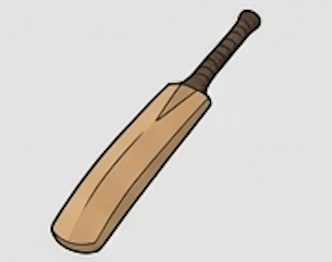

In [ ]:
get_image(234)

In [ ]:
# adapter_path="trained_phi2_gpt_model"
# peft_llama = peft.PeftModel.from_pretrained(llama, adapter_path)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


# **Training**

In [ ]:

# LAMBDA_LB_FINETUNE = 1e-4   # smaller λ during fine-tuning (task-specific queries, paper §3.2)


# Paper §4.7.2: best TGIF model (trained on 665K samples) uses LB in Stage-1 ONLY.
# With only 234 samples, CE loss alone gives insufficient routing signal; the router
# stays frozen at the near-uniform state it reached during Stage 1.
# A very small λ=5e-4 nudges the router away from that plateau without over-regularising.
# Set LAMBDA_LB_FINETUNE = 0 to match the paper exactly (only recommended for ≥100K samples).

LAMBDA_LB_FINETUNE = 5e-4


def run_train_fine_tune():
    phi2_proj_model.train()
    for idx, batch in enumerate(dataloader):
        torch.set_grad_enabled(True)
        pil_img_lst = []
        for image_name in batch['image_names']:
            print("image_name ", image_name)
            image = get_image(image_name)
            if image:
                pil_img_lst.append(image)

        print("length", len(pil_img_lst))

        qn_tokens     = batch['qn'].to(device)
        ans_tokens    = batch['ans'].to(device)
        target_tokens = batch['ans'].to(device)
        print("target_tokens", target_tokens)
        T_ = target_tokens.shape[-1]
        Q_ = qn_tokens.shape[-1]
        print(f'T_ : {T_}, qn_tokens.shape : {qn_tokens.shape}, target_tokens:{target_tokens.shape}, a:{ans_tokens.shape}')

        output, input_embed, inputs_given = phi2_proj_model(pil_img_lst, qn_tokens, target_tokens)
        print(f'input_embed.shape : {input_embed.shape} output.logits.shape : {output.logits.shape}, inputs_given.shape :{inputs_given.shape}')
        print(len(output))
        print("output", output)

        ans_pos    = 49 + 4 + Q_ + 3
        print(f'T_ : {T_+1} == {input_embed.shape[1]-ans_pos}')
        pred_logits = output.logits[:, ans_pos+1:, :]
        print(f'pred_logits.shape : {pred_logits.shape}')

        B, T, C = pred_logits.shape
        print('B, T, C ', B, T, C)
        pred_logits_flat = pred_logits.reshape(B * T, C)
        print('pred_logits', pred_logits_flat)
        preds       = F.softmax(pred_logits_flat, dim=-1).to(torch.float32)
        top_prob    = torch.multinomial(preds, num_samples=1)
        display_ids = top_prob.view(B, T)

        eos_tensor  = torch.full((B, 1), eos_token_id, dtype=torch.int64).to(device)
        targets     = torch.cat((target_tokens, eos_tensor), dim=1)
        print('targets', targets)
        tgts        = targets.reshape(B * (T_ + 1))
        print('tgts', tgts)

        out_text = tokenizer.batch_decode(display_ids)
        in_text  = tokenizer.batch_decode(inputs_given)
        print(f'idx : {idx}')
        print(f"inp: {in_text[0]}")
        print(f"pred: {out_text[0]}")
        print(f'tgt: {tokenizer.batch_decode(targets)[0]}')
        print(f"GT-QN: {tokenizer.decode(batch['qn'][0])}")
        print(f"GT-ANS: {tokenizer.decode(batch['ans'][0])}")
        # # TGIF load-balancing loss for fine-tuning (smaller λ, paper §3.2 & §4.7.2)
        # ce_loss       = F.cross_entropy(pred_logits_flat, tgts)

        layer_weights = phi2_proj_model.last_layer_weights        # [B, L]
        w_bar         = layer_weights.mean(dim=0)                 # [L]
        entropy       = -(w_bar * torch.log(w_bar + 1e-8)).sum().item()

        # TGIF: paper uses λ=0 in Stage-2 for 665K samples. For 234 samples, a tiny
        # LB push (LAMBDA_LB_FINETUNE=5e-4) breaks the uniform plateau from Stage 1.
        # lb_loss = +Σ(w·log w) = -H  →  minimising this maximises entropy (diverse routing).
        ce_loss = F.cross_entropy(pred_logits_flat, tgts)
        lb_loss = LAMBDA_LB_FINETUNE * (w_bar * torch.log(w_bar + 1e-8)).sum()  # -λ·H
        loss    = ce_loss

        loss.backward()
        optimizer.step()
        scheduler.step()       # cosine LR decay with warmup (paper §C Appendix)
        optimizer.zero_grad()

        if idx % 5 == 0:  # print every 5 batches
            router_lr = scheduler.get_last_lr()[2]   # group[2] = tgif_router
            proj_lr   = scheduler.get_last_lr()[0]   # group[0] = proj_lin_layer
            print(f'idx: {idx}, loss: {loss:.4f}  ce: {ce_loss:.4f}  lb: {lb_loss:.6f}  tgt-len: {T_} '
                  f'entropy: {entropy:.4f}  w_bar_max: {w_bar.max():.4f}  w_bar_min: {w_bar.min():.4f}  '
                  f'router_lr: {router_lr:.2e}  proj_lr: {proj_lr:.2e}')




In [ ]:
NUM_EPOCHS_STAGE2=20
for _ in range(NUM_EPOCHS_STAGE2):
    run_train_fine_tune()
    time.sleep(10)

Streaming output truncated to the last 5000 lines.
        [ 4.2529,  0.1366,  4.0008,  ..., -2.5054, -2.5046, -2.5046],
        [ 4.8109,  0.0622,  4.6928,  ..., -2.0356, -2.0349, -2.0348]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>)
targets tensor([[128000,   4054,  16120,   6982,  10269,    323,   3185,  10539,    304,
            264,    220,     17,     35,   1684,     13, 128001],
        [128000,   2822,     11,   1070,    374,    912,  16120,    477,   5041,
            304,    420,   2217,     13, 128001, 128001, 128001]],
       device='cuda:0')
tgts tensor([128000,   4054,  16120,   6982,  10269,    323,   3185,  10539,    304,
           264,    220,     17,     35,   1684,     13, 128001, 128000,   2822,
            11,   1070,    374,    912,  16120,    477,   5041,    304,    420,
          2217,     13, 128001, 128001, 128001], device='cuda:0')
idx : 186
inp: <|begin_of_text|>caption image:<|begin_of_text|>How many cricket bats appear in this flat horizontal

In [ ]:
torch.save(phi2_proj_model.proj_lin_layer.state_dict(), 'phi2_proj_projm_2.pth')
torch.save(phi2_proj_model.proj_model.state_dict(),     'phi2_proj_model_2.pth')
torch.save(phi2_proj_model.tgif_router.state_dict(),    'tgif_router_2.pth')   # TGIF Stage 2

peft_llama.save_pretrained("trained_phi2_gpt_model_tgif1")
# torch.save(phi2_proj_model.llama.state_dict(), 'llama2.pth')

# phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('/content/gdrive/MyDrive/ERA1/capstone/phi2_proj_model_offset_ll.pth'))
# phi2_proj_model.proj_model.load_state_dict(torch.load('/content/gdrive/MyDrive/ERA1/capstone/phi2_proj_model_offset_projmodel.pth'))
# phi2_proj_model.llama.load_state_dict(torch.load('/content/gdrive/MyDrive/ERA1/capstone/phi2_proj_model_offset_phi2.pth'))


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1419: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6a10591d-3a1f06112cf9c4f74a42f078;b6240916-2ec8-47cc-9e9d-537698201319)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-1B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-1B is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-1B.
  warnings.warn(


# **After Stage 2 VQA Training - Model Inference Check:**

In [ ]:

import os
import gc
import json
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import random
import numpy as np
from PIL import Image
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DataCollatorWithPadding, AutoProcessor
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig
import peft
from peft import LoraConfig
from peft import PeftModel
import requests
from io import BytesIO


adapter_path="trained_phi2_gpt_model_tgif"
merged_phi2 = peft.PeftModel.from_pretrained(llama, adapter_path)


tokenizer.pad_token = tokenizer.eos_token
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id

eoc_string = 'caption image:'
eoc_tokens = tokenizer.encode(eoc_string)
print(f'eoc_tokens : {eoc_tokens}')

eoq_string = 'end of question:'
eoq_tokens = tokenizer.encode(eoq_string)
print(f'eoq_tokens : {eoq_tokens}')

print(bos_token_id, pad_token_id, eos_token_id)
print(tokenizer.decode([50256, 50256, 50256]))
print('eoc tokens decoded:', tokenizer.decode(eoc_tokens))
print('eoq tokens decoded:', tokenizer.decode(eoq_tokens))
print(len(tokenizer))

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


eoc_tokens : [128000, 24232, 2217, 25]
eoq_tokens : [128000, 408, 315, 3488, 25]
128000 128001 128001
parableparableparable
eoc tokens decoded: <|begin_of_text|>caption image:
eoq tokens decoded: <|begin_of_text|>end of question:
128256


In [ ]:
class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        return x + self.proj(x)


# ============================================================
# TGIF Phi2ProjModel — Stage 3 (inference / generation)
#
# Changes vs dense connector:
#   • Receives tgif_router
#   • clip_embed_dim = 768
#   • forward takes input_embed and generates (routing done in prepare_input_embed)
# ============================================================

class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama,
                 tgif_router,
                 clip_embed_dim=CLIP_HIDDEN_DIM,
                 phi2_dim=LLM_HIDDEN_DIM):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim       = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)
        self.clip_model     = clip_model
        self.clip_processor = clip_processor
        self.proj_model     = proj_model
        self.llama     = llama
        self.tgif_router    = tgif_router   # TGIF router for inference routing

    def forward(self, input_embed):
        max_len = 60
        print("shape of input_embed", input_embed.shape)
        output = self.llama.generate(
            inputs_embeds=input_embed,
            max_new_tokens=max_len,
            num_beams=5,
            early_stopping=True,
            do_sample=False,
            return_dict_in_generate=True,
            output_hidden_states=True,
            bos_token_id=bos_token_id,
            pad_token_id=bos_token_id,
            eos_token_id=bos_token_id
        )
        return output


# ---- Instantiate Stage 3 model with trained TGIF router ----

tgif_router      = TGIFRouter(text_dim=LLM_HIDDEN_DIM, num_layers=NUM_CLIP_LAYERS).to(device)
projection_layer = ClipProjectionBlock(LLM_HIDDEN_DIM).to(device)
phi2_proj_model  = Phi2ProjModel(
    clip_model, clip_processor, projection_layer, merged_phi2,
    tgif_router
).to(device)

# TGIF NOTE: proj_lin_layer 1536→768; load TGIF Stage 2 checkpoint here.
phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phi2_proj_projm_2_load.pth'))
phi2_proj_model.proj_model.load_state_dict(torch.load('phi2_proj_model_2_load.pth'))    # compatible
phi2_proj_model.tgif_router.load_state_dict(torch.load('tgif_router_2_load.pth'))       # TGIF Stage 2


<All keys matched successfully>

In [ ]:

def prepare_input_embed(img=None, audio=None, text=None, extra=None):
    """
    Build the final input embedding for Stage-3 inference.

    TGIF change:
      1. Run CLIP → extract all layer hidden states [1, L, 49, 768]
      2. Pre-compute LLM text embedding from the question → f_text [1, 2048]
      3. Route CLIP layers via tgif_router    → layer_weights [1, L]
      4. Fuse layers                          → clip_embeddings [1, 49, 768]
      5. Project and concatenate with text embed (same as dense connector)
    """
    input_embed_exists = 0
    inputs_given       = []

    # TGIF: pre-compute text embedding for router (we need it before image processing)
    if text is not None:
        text_tkn_for_router = torch.tensor(text, dtype=torch.int64).to(device).unsqueeze(0)
        with torch.no_grad():
            t_emb_for_router = phi2_proj_model.llama.model.model.embed_tokens(
                text_tkn_for_router
            )
        f_router_text = t_emb_for_router.mean(dim=1)    # [1, 2048]
    else:
        f_router_text = torch.zeros(1, LLM_HIDDEN_DIM, device=device)

    if img is not None:
        inputs      = clip_processor(images=img, return_tensors="pt").to(device)
        clip_output = clip_model(**inputs, output_hidden_states=True)

        # TGIF: extract layer hs then route + fuse
        layer_hs        = extract_layer_hidden_states(clip_output)             # [1, L, 49, 768]
        layer_weights   = phi2_proj_model.tgif_router(f_router_text)           # [1, L]
        clip_embeddings = tgif_fuse_layers(layer_hs, layer_weights)            # [1, 49, 768]

        image_embed = phi2_proj_model.proj_lin_layer(clip_embeddings)          # [1, 49, 2048]
        image_embed = phi2_proj_model.proj_model(image_embed)                  # [1, 49, 2048]
        B, _, C     = image_embed.shape

        eoc_tkn_tensor    = torch.tensor(eoc_tokens, dtype=torch.int64).to(device)
        eoc_tensor        = eoc_tkn_tensor.repeat(B, 1)
        eoc_embed         = phi2_proj_model.llama.model.model.embed_tokens(eoc_tensor)

        input_image_embed = torch.cat([image_embed, eoc_embed], dim=1)
        input_image_embed = input_image_embed.to(dtype=torch.float16)
        print("image embd", input_image_embed)

    if text is not None:
        text_tkn_tensor = torch.tensor(text, dtype=torch.int64).to(device)
        text_tkn_tensor = text_tkn_tensor.unsqueeze(0)
        text_embed      = phi2_proj_model.llama.model.model.embed_tokens(text_tkn_tensor)
        print("text embd", text_embed)

    if extra is not None:
        extra_tkn_tensor = torch.tensor(extra, dtype=torch.int64).to(device)
        extra_tkn_tensor = extra_tkn_tensor.unsqueeze(0)
        extra_embed      = phi2_proj_model.llama.model.model.embed_tokens(extra_tkn_tensor)
        print("extra embd", extra_embed)

    if img is not None:
        input_embed        = input_image_embed
        input_embed_exists = 1

    if text:
        if input_embed_exists:
            if audio is not None:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
            else:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
        else:
            input_embed        = text_embed
            input_embed_exists = 1
        inputs_given.append(text)

    inputs_given.append(eoq_tokens)
    print("input given is ", inputs_given)

    eoq_tkn_tensor = torch.tensor(eoq_tokens, dtype=torch.int64).to(device)
    B          = 1
    eoq_tensor = eoq_tkn_tensor.repeat(B, 1)
    eoq_embed  = phi2_proj_model.llama.model.model.embed_tokens(eoq_tensor)

    input_embed = torch.cat([input_embed, eoq_embed, extra_embed], dim=1)
    print("final input embd", input_embed)

    print("--- Input Sequence Breakdown ---")
    print(f"Image Marker: {tokenizer.decode(eoc_tokens)}")
    print(f"Question Text: {tokenizer.decode(text)}")
    print(f"Question Closer: {tokenizer.decode(eoq_tokens)}")
    print("\n--- Full Combined String ---")
    full_string = tokenizer.decode(eoc_tokens) + tokenizer.decode(text) + tokenizer.decode(eoq_tokens)
    print(full_string)

    return input_embed

In [ ]:
id= 79
text = instruct150k_caption[id]
print(text)

Boy in batting stance, bat raised behind shoulder, ready.


In [ ]:
text, question, answer = instruct150k_qa[id]
print(text, question, answer)

Boy in batting stance, bat raised behind shoulder, ready. How many objects present in this image? This image has 1 bat and no ball.


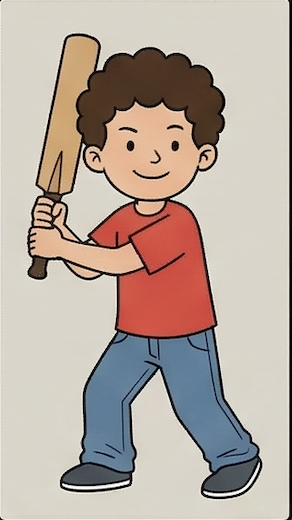

In [ ]:
get_image(id)

In [ ]:


def gradio_get_answers_fn2(image=None, audio=None, text=None):
    audio_tokens = None
    text_tokens  = None

    text = "How many objects are present in this image? "
    print("text is", text)
    if text:
        text_tokens = tokenizer.encode(text)
        print("text_input", tokenizer.decode(text_tokens))

    extra        = ":<|begin_of_text|>"
    extra_tokens = tokenizer.encode(extra)

    if image:
        if audio or text:
            pass
        else:
            text        = "Please describe this image."
            text_tokens = tokenizer.encode(text)
            print("image input", tokenizer.decode(text_tokens))

    if image or audio or text:
        input_embed = prepare_input_embed(image, audio_tokens, text_tokens, extra_tokens)
        with torch.no_grad():
            output   = phi2_proj_model(input_embed)
            print("my output is ", output)
            out_text = tokenizer.batch_decode(output.sequences)[0]
            print(out_text)
    else:
        out_text = "I didn't get any input. Give me an image/audio/text or combination of these 3 and get the answer back !"

    return out_text

In [ ]:
import gradio as gr

markdown_description = """
Multimodal llm with image question capabilities
"""
demo = gr.Interface(fn=gradio_get_answers_fn2,
                    inputs=[
                            gr.Image(type="pil", label="Image"),
                            gr.Textbox(info="How may I help you ? please enter your prompt here...", label="Text Query")
                           ],
                    outputs=gr.Textbox(label="Response"),
                    title="Answer image query",
                    description=markdown_description,
                    article="tp")
demo.queue().launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://19f24a00b2e9cc8e4e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Streaming output truncated to the last 5000 lines.
         [-1.1160e+00,  5.6971e-01,  3.2551e-01,  ...,  8.5365e-01,
           6.2905e-01,  5.5371e-01],
         [-1.6708e+00,  7.7566e-01,  4.9806e-01,  ...,  1.7275e+00,
           1.0004e+00,  1.3613e+00],
         ...,
         [ 9.0940e-03, -4.3711e-02,  3.9694e-02,  ...,  6.9942e-03,
           8.2978e-02,  3.6376e-03],
         [-1.4106e-03, -1.5433e-02,  1.1349e-02,  ..., -1.4579e-02,
           8.2040e-03,  4.3659e-02],
         [ 1.3299e-02, -4.4725e-02,  4.1798e-02,  ...,  6.8456e-03,
           8.4732e-02,  2.5426e-03]]], device='cuda:0'), tensor([[[-9.6631e-01,  6.4745e-01,  1.5421e+00,  ...,  1.4150e+00,
           9.8294e-01,  1.2612e+00],
         [-1.2512e+00,  6.7365e-01,  2.9914e-01,  ...,  8.7227e-01,
           8.2234e-01,  5.2977e-01],
         [-1.8067e+00,  8.4115e-01,  4.9151e-01,  ...,  1.7370e+00,
           1.1738e+00,  1.3758e+00],
         ...,
         [ 8.6729e-02, -8.3341e-02,  4.3168e-01,  ...,  2.259

# **Experiment**

# **Experiments Prep for Probing**

In [ ]:

CATEGORY_PROBES = {
    'existence'   : 'Is there a cricket bat visible in this image?',
    'counting'    : 'How many cricket bats are visible in this image?',
    'attribute'   : 'What color is the cricket ball in this image?',
    'spatial'     : 'Is the batsman on the left or right side of the image?',
    'descriptive' : 'Describe what is happening in this cricket image.',
    'fine_grained': 'Is the batsman in a defensive or attacking stance?',
}

In [ ]:
import re

# ============================================================
# MASTER DATASET MAPPING (376 Questions Across 6 Categories)
# ============================================================
RAW_CATEGORIZED_QUESTIONS = {
    "Counting": [
        "How many cricket bats is the boy holding?", "How many hands grip the bat in this close-up?",
        "How many cricket balls are on the ground?", "How many balls are present and where?",
        "How many bats is the boy holding?", "How many bats are gripped in this close-up?",
        "How many bats are shown and where?", "How many bats and how are they arranged?",
        "How many bats and balls are in this image?", "How many bats are visible in this image?",
        "How many bats are present in this image?", "How many cricket bats are raised in this image?",
        "How many cricket objects appear in this scene?", "How many bats are present in this overhead view?",
        "How many bats and balls appear in this swing scene?", "How many balls are on the ground in this image?",
        "How many bats and balls appear in this image?", "How many bats and balls does the boy have?",
        "How many cricket bats are being gripped in this image?", "How many cricket balls surround the boy?",
        "How many bats are leaning in this image?", "How many cricket bats are lying flat here?",
        "How many bats and balls are visible here?", "How many cricket bats are crossed in this image?",
        "How many cricket bats can you count in this scene?", "How many cricket bats is the boy holding in the hand?",
        "How many bats is the boy using to prepare his swing?", "How many bats does the boy carry in this image?",
        "How many proper cricket bats are visible in this image?", "How many cricket bats appear in this image?",
        "How many cricket bats does the boy hold here?", "How many bats is the boy holding in total?",
        "How many hands are gripping the bat handle?", "How many arrows appear in this image?",
        "How many bats does the boy hold in this alert stance?", "How many pieces of sports equipment are visible?",
        "How many bats are visible in this rear-view image?", "How many cricket bats does the boy hold?",
        "How many bats does the boy extend outward?", "How many bats are raised in this image?",
        "How many players are visible in this image?", "How many bats are in motion in this image?",
        "In how many hands does the boy hold the bundled bats?", "What number of bats does the red X icon draw attention to?",
        "What is the count of distinct hand grips visible on the bat?", "How many contact points between hands are marked by the arrow?",
        "What is the number of red balls visible on the ground around the boy?", "How many cricket balls appear in this scene in total?",
        "Count the number of cricket balls visible in this aerial shot.", "How many bats are crossed beneath the stacked balls?",
        "What is the total count of bats the boy is holding?", "How many bats are shown in total in this close-up view?",
        "What number of cricket balls form the complete ring around the boy?", "What is the count of bats standing against the wall?",
        "How many bat blades overlap at the centre of this arrangement?", "How many objects are in this image?",
        "How many cricket bats is the boy holding in this image?", "How many bats does the boy have raised behind his shoulder?",
        "How many bats is the boy carrying in this image?", "What is the total number of cricket bats visible in this image?",
        "How many question mark icons are visible in this image?", "Count the question mark icons floating in this image.",
        "How many objects and different kind is the boy holding?", "What number of bats does the boy hold simultaneously?",
        "How many hands are gripping the bat handle in this close-up?", "Count the cricket bats visible in this image.",
        "How many bats does the boy hold in this alert pose?", "What is the total number of cricket equipment pieces the boy has?",
        "How many hands does the boy use to hold the bat?", "How many bats appear in this rear-view image?",
        "What number of cricket bats does the boy hold?", "How many bats does the boy extend outward in this image?",
        "Count the bats raised in this image.", "How many players are visible in this rear-view image?",
        "How many bats appear in this close-up portrait?", "What is the count of bats visible in this rear close-up?",
        "How many hands are visible gripping the bat handle?", "How many bats are visible in this defensive shot pose?",
        "How many knees are on the ground in this celebratory pose?", "How many feet are stepped forward during this bat swing?",
        "How many bats does the boy have raised in this stance?", "How many bats are planted blade-down in this image?",
        "How many people appear in this overhead image?", "How many hands are on the bat handle in this close-up?",
        "How many bats are propped beside the boy?", "What is the total number of cricket bats present in this image?",
        "How many objects lie beside the boy in this top-down view?", "How many bats does the boy raise overhead in this back-swing?",
        "How many shoulders have a bat resting on them in this close-up?", "How many cricket bats does the boy hold from this rear angle?",
        "How many bats lie beside the boy in this top-down image?", "Count the bats shown in motion in this image.",
        "How many fists are clenched in this celebration image?", "How many items of cricket equipment does the boy hold?",
        "How many hands grip the bat handle in this close-up?", "How many impact marks are visible on the bat?",
        "How many red cricket balls are on the ground?", "What is the total number of cricket balls visible in this scene?",
        "How many bats does the boy carry in this rear-view shot?", "How many cricket balls are spread around the boy in this aerial view?",
        "How many bats are crossed over the boy's shoulders?", "Count the number of bats bundled together in this image.",
        "How many objects does the boy hold in total?", "How many cricket balls are stacked on top of the crossed bats?",
        "How many objects does the boy carry in this image?", "How many cricket balls are shown in this bat-strike close-up?",
        "What is the total number of bats the boy is holding?", "How many bats are being gripped in this close-up?",
        "How many cricket balls appear in this close-up?", "Approximately how many red cricket balls encircle the boy?",
        "How many people are visible in this image?", "How many hands does the boy clasp together in this pose?",
        "How many pieces of sports equipment are visible in this image?", "How many people appear in this three-quarter side-profile image?",
        "How many hands does the boy clasp in this front-facing pose?", "How many arms are visible in this rear-view standing image?",
        "How many legs are visible in this walking pose?", "How many people appear in this left side-profile image?",
        "How many people are visible in this rear close-up?", "How many knees are raised in this bending pose?",
        "How many arms are raised wide during this jump?", "How many people are captured mid-jump in this image?",
        "How many knees are on the ground in this kneeling pose?", "How many cricket bats are leaning against the wall?",
        "Count the bats lying flat in this image.", "How many cricket bats appear in this flat horizontal view?",
        "How many ridges are visible on the bat face in this diagonal view?", "How many bats are standing vertically in this image?",
        "How many distinct subjects can be identified in this narrow strip?", "How many cricket bats are crossed in this arrangement?",
        "How many bat handles are visible in this close-up?", "How many shadows are cast by the bat in this diagonal view?"
    ],
    "Spatial": [
        "What is the boy's stance in this image?", "In which direction is the bat angled?",
        "From which view is the boy shown?", "How is the bat oriented?",
        "In which direction is the bat raised?", "What is the boy doing with his foot?",
        "From what camera angle is this captured?", "How are the hands positioned on the handle?",
        "From what angle is the boy viewed?", "What pose is shown from the rear?",
        "Which shoulder is the bat resting on?", "What angle is used and what surrounds the boy?",
        "How are the two bats positioned?", "From what angle is the boy shown here?",
        "Which side profile is shown?", "How is the bat oriented in this view?",
        "How is the bat oriented in this flat view?", "How is the bat oriented in this illustration?",
        "Where is the bat positioned in this batting stance?", "Where is the bat held relative to the boy's body?",
        "Where is the bat positioned in this rear view?", "How is the bat positioned across the boy's body?",
        "What motion is the bat showing in this image?", "Where is the bat positioned in this relaxed pose?",
        "From which angle is this batting image taken?", "Where is the bat positioned relative to the boy in this overhead view?",
        "Where is the bat during the back-swing?", "Where is the bat resting in this side-profile image?",
        "Where are the balls positioned relative to the bat?", "How are the two bats arranged in this image?",
        "Where are the balls positioned relative to the bats?", "From which side is the boy photographed?",
        "Where are the boy's arms during this jump?", "Where is the boy positioned in this image?",
        "What view of the bat is shown in this image?", "What feature is visible on the bat in this diagonal view?",
        "What objects surround the boy in this bird's-eye view?", "Where on his body are the boy's hands positioned?",
        "Where are the boy's arms relative to his body?", "Where is the boy's leading foot placed?",
        "From which side is the boy's profile shown?", "Which region of the body is the focus of this rear close-up?",
        "Where is the boy's raised knee positioned in this view?", "Where are the boy's arms positioned during the jump?",
        "Where are the boy's legs positioned compared to the previous jump image?", "Where is the boy positioned relative to the ground?",
        "Where are the two bats placed in this image?", "Where is the blade of the bat positioned in this diagonal view?",
        "Which side is the blade on in this flat horizontal view?", "Where is the central ridge located on the bat face?",
        "Where is the blade relative to the handle in this upright view?", "Where is the visible content located within the image frame?",
        "Where do the three bat handles point relative to each other?", "Which part of the bat is shown in the foreground of this close-up?",
        "Where does the shadow fall relative to the bat in this diagonal view?", "Where are the boy's eyes directed in this front-facing image?",
        "Where is the boy's weight distributed in this rear-view standing pose?", "From which direction is the three-quarter view captured?",
        "Which side of the body is facing away from the camera?", "Where is the boy's body weight concentrated in this bending pose?",
        "Where are the boy's legs positioned relative to his torso during the jump?", "Where are the arms positioned relative to the body centre in this jump?",
        "Where are the boy's arms placed in this kneeling rear-view pose?", "Where does the handle of the bat point in this diagonal view?",
        "Where is the top edge of the bat located in this flat horizontal view?", "In which region of the bat is the central ridge most visible?",
        "Where does the bat make contact with the ground in this upright view?", "On which side of the bat does the shadow extend in this diagonal view?"
    ],
    "Fine-grained": [
        "What batting action is the boy preparing?", "What does the red X icon indicate here?",
        "What does the arrow in the image indicate?", "What batting action does this posture suggest?",
        "What batting stroke is being performed?", "What is prominent in this close-up rear view?",
        "What feature is visible on the bat face?", "Which part of the bat is shown?",
        "What color is the background in this bat close-up?", "What part of the bat is visible in this close-up?",
        "How are the hands arranged on the bat grip?", "Where on the bat is the impact mark visible?",
        "What distinctive feature is visible in this close-up?", "What is the boy's pose in this rear view?",
        "Is a cricket bat standing upright in this image?", "Is this a close-up of a cricket bat handle?",
        "What part of the bat is being gripped in this close-up?", "What surface mark is visible at the bat toe?",
        "What colour are the cricket balls on the ground?", "What additional cricket item does the boy hold besides the bat?",
        "What is the material difference between the two objects he holds?", "What is placed on top of the two crossed bats?",
        "What visual effect indicates the force of the bat-ball contact?", "What action do the arc motion lines represent?",
        "What is shown for each of the three bats in this close-up?", "What two cricket items are in contact in this close-up?",
        "What texture or feature is visible on the bat handle in this close-up?", "What does the downward bat angle and toe mark reveal about the shot played?",
        "What colour are the balls visible on the ground in this rear-view image?", "What does the X pattern formed by the crossed bats visually signal?",
        "Which body part are the three bundled bats pressed against?", "What is the colour difference between the cricket bat and the tree branch?",
        "What is the material of the non-cricket object the boy holds?", "What does the direction of the blur lines indicate about the bat swing?",
        "What does the hand pressing the ball onto the blade suggest about bat care?", "What technical detail of the bat is highlighted in this close-up?"
    ],
    "Existence": [
        "Is the object the boy holds a cricket bat?", "Does the boy have any sports equipment?",
        "Is there a person in this image?", "Is the boy holding any cricket equipment?",
        "Is there a cricket bat visible in this image?", "Is any cricket equipment visible in this image?",
        "Is a cricket bat or ball visible in this scene?", "Is there a cricket bat in this image?",
        "Are there any balls visible in this image?", "Is the boy holding a bat in this image?",
        "Is a cricket bat raised in this celebration image?", "Is a cricket bat visible in this scene?",
        "Is there a genuine cricket bat in this image?", "Is a cricket bat being gripped in this close-up?",
        "Is there a real cricket bat in this image?", "Is the boy holding a cricket bat in this image?",
        "Are both a bat and a ball visible in this image?", "Is there any cricket equipment in this image?",
        "Can you find a bat or ball in this image?", "Does the boy have any cricket gear here?",
        "Are there any cricket bats or balls in this scene?", "Is the boy resting a bat on his shoulder in this image?",
        "Is a bat visible from this rear-view perspective?", "Is only one hand gripping the bat handle in this close-up?",
        "Is a cricket ball present in this overhead image?", "Are both hands visible on the bat handle in this close-up?",
        "Is a fence visible in this image?", "Is the boy in a batting stance in this image?",
        "Is any sports equipment other than the bat visible?", "Is a full back-swing visible from the rear perspective?",
        "Is the bat resting on the boy's right shoulder?", "Is the object the boy holds a proper cricket bat?",
        "Does the X icon indicate that the object held is incorrect equipment?", "Is the object the boy holds in this image a recognised cricket item?",
        "Can any cricket-specific equipment be identified in this scene?", "Does the boy appear to be holding anything in this side-profile image?",
        "Can any field markings or pitch lines be seen in this bird's-eye view?", "Is the boy standing on the inside of a fenced area?",
        "Does the overhead view reveal any shadows cast by the boy or bat?", "Can you confirm from the rear view that the object is not a cricket bat?",
        "Is a coloured background visible beneath the boy in this top-down image?", "Is any bat or cricket equipment visible in this rear close-up?"
    ],
    "Attribute": [
        "What is the boy holding in this image?", "What is unusual about the object he holds?",
        "What is the boy holding and why is it wrong?", "What is the background colour in this image?",
        "How is the boy holding the bat?", "What is the boy doing with the bat?",
        "How does the background differ from most images?", "What emotion is the boy expressing?",
        "How does this background differ from images 21-30?", "Is the object a proper cricket bat?",
        "How does this compare to image 33?", "What non-cricket object is the boy holding?",
        "What two cricket items are shown here?", "How does his expression compare to image 57?",
        "What pose is the boy in?", "What position is the boy in?",
        "What makes this image unusual?", "How does this differ from image 71?",
        "Is there more than one bat visible in this close-up?", "How is the bat held in this image?",
        "What color is the background in this image?", "What color is the background in this batting image?",
        "What is the boy holding in each hand?", "Is a ball in contact with the bat in this close-up?",
        "What is the boy's expression in this image?", "What is the boy doing in this rear-view image?",
        "What is the boy doing in this image?", "Is boy using both the hands to hold the bat?",
        "What is the boy's body orientation in this image?", "What shape do the two crossed bats form?",
        "How are the three bats held?", "What non-cricket object is present in this image?",
        "What is the arrangement pattern of the balls around the boy?", "What colour is the boy's shirt?",
        "What facial expression does the boy show?", "What body-orientation type is shown in this image?",
        "Does the boy adopt a wide stance during this bat swing?", "Is the bat raised above shoulder height in this image?",
        "Is the boy holding equipment in both hands simultaneously?", "What clothing item is most prominent in this standing pose?",
        "How would you describe the boy's overall body posture in this image?", "What emotion does the boy's body language convey?",
        "What camera angle is used to capture the boy in this image?"
    ],
    "Descriptive": [
        "How is the boy carrying the cricket bat?", "What does the boy's posture suggest?",
        "What action is the boy performing?", "What is the boy doing with the bat here?",
        "From which perspective is the boy shown?", "What is the boy standing behind?",
        "What do the motion lines indicate?", "What is the boy celebrating?",
        "What two cricket items is the boy holding?", "What does the impact mark near bat toe suggest?",
        "How is the boy's body oriented?", "What differs between the two objects held?",
        "What is happening at point of contact?", "What do the arc motion lines indicate?",
        "How are the balls arranged around the boy?", "What is the boy doing with his hands?",
        "What emotion does the jumping pose express?", "How does this compare to the previous jump image?",
        "Where is the bat in this celebration pose?", "How many balls are spread around the boy?",
        "Is the boy performing a defensive batting shot?", "Is the boy in a celebratory pose?",
        "Is the boy's front foot stepped forward during the swing?", "Is the bat raised toward the upper-left in this image?",
        "Is the bat planted blade-down on the ground?", "Is the boy shown from a top-down angle?",
        "Are motion lines present in this image?", "Is the boy expressing a celebratory emotion?",
        "Is the boy holding any head-protection gear?", "How would you summarise the mood and content of this image?",
        "What preparation stage does this image capture?", "What does the boy's posture and bat position suggest about the context?",
        "What does the horizontal bat position tell us about the type of stance?", "What can be inferred about the batsman's readiness from this image?",
        "What does holding the bat close to the chest with both hands indicate?", "What does the rear-view walking pose suggest about the situation?",
        "What does the diagonal bat position across the body suggest?", "What activity is the boy performing with the bat in this rear-side view?",
        "What contrast does the dark grey background create in this image?", "What mood or attitude does the foot-on-bat pose convey?",
        "What impression does the narrow horizontal framing create in this image?", "What does the crouched rear-view posture tell us about the batsman's intent?",
        "Which batting stroke family does the horizontal mid-swing suggest?", "What does resting the bat over the shoulder typically indicate in cricket?",
        "What does the left-shoulder bat-raise from a rear angle suggest about handedness?", "What batting coaching point does a single-hand grip close-up typically illustrate?",
        "What delivery type is the forward defensive posture designed to counter?", "What milestone achievement does the knee-down celebration typically follow?",
        "What footwork principle does the front-foot step with the horizontal swing demonstrate?", "What does the diagonal upper-left backswing reveal about the intended shot direction?",
        "What coaching point does the two-handed close-up typically demonstrate?", "What body alignment principle is illustrated by this defensive batting stance?",
        "What aspect of batting power generation does the overhead back-swing demonstrate?", "What purpose does the side-profile angle serve when analysing the bat-carry stance?"
    ]
}

# ── Helper to standardize key normalization ──
def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', '', text)  # Strip punctuation (?, ., ', etc.)
    return " ".join(text.split())        # Normalize variable whitespaces

# ── Precompile Lookup Map for O(1) Performance ──
QUESTION_LOOKUP_MAP = {}
CATEGORY_NAME_MAPPING = {
    "Counting": "counting",
    "Spatial": "spatial",
    "Fine-grained": "fine_grained",
    "Existence": "existence",
    "Attribute": "attribute",
    "Descriptive": "descriptive"
}

for raw_cat, questions in RAW_CATEGORIZED_QUESTIONS.items():
    target_slug = CATEGORY_NAME_MAPPING[raw_cat]
    for q_text in questions:
        QUESTION_LOOKUP_MAP[normalize_text(q_text)] = target_slug

# ============================================================
# IMPROVED CATEGORIZATION FUNCTION
# ============================================================
def get_category_by_rules(question_text):
    """
    Categorizes cricket VQA questions cleanly into the 6 verified categories.
    Uses exact lookup for known questions, and a robust fallback regex matching structure.
    """
    cleaned_q = normalize_text(question_text)

    # 1. Direct Lookup Check (100% Accuracy for dataset items)
    if cleaned_q in QUESTION_LOOKUP_MAP:
        return QUESTION_LOOKUP_MAP[cleaned_q]

    # Absolute Fallback
    return 'no'

# **Experiment 2 - Probing the Router: Relative Noise Injection Stress Test**


════════════════════════════════════════════════════════════
  RULE-BASED CATEGORY DISTRIBUTION SUMMARY (TGIF)
════════════════════════════════════════════════════════════
  • existence       :     43 items (  9.2%)
  • counting        :    216 items ( 46.2%)
  • attribute       :     44 items (  9.4%)
  • spatial         :     71 items ( 15.2%)
  • descriptive     :     58 items ( 12.4%)
  • fine_grained    :     36 items (  7.7%)
  ────────────────────────────────────────────────────────────
  Total Dataset Size :    468 items
════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════════════════════════════════════════════
  Approach 3 (TGIF Router) — Isolated Noise Injection Tracking Core Performance Matrix
═════════════════════════════════════════════════════════════════════════════════════════════════════════

  ── Category: existence ──
  ────────────────────────────────────────────────────────────────────────

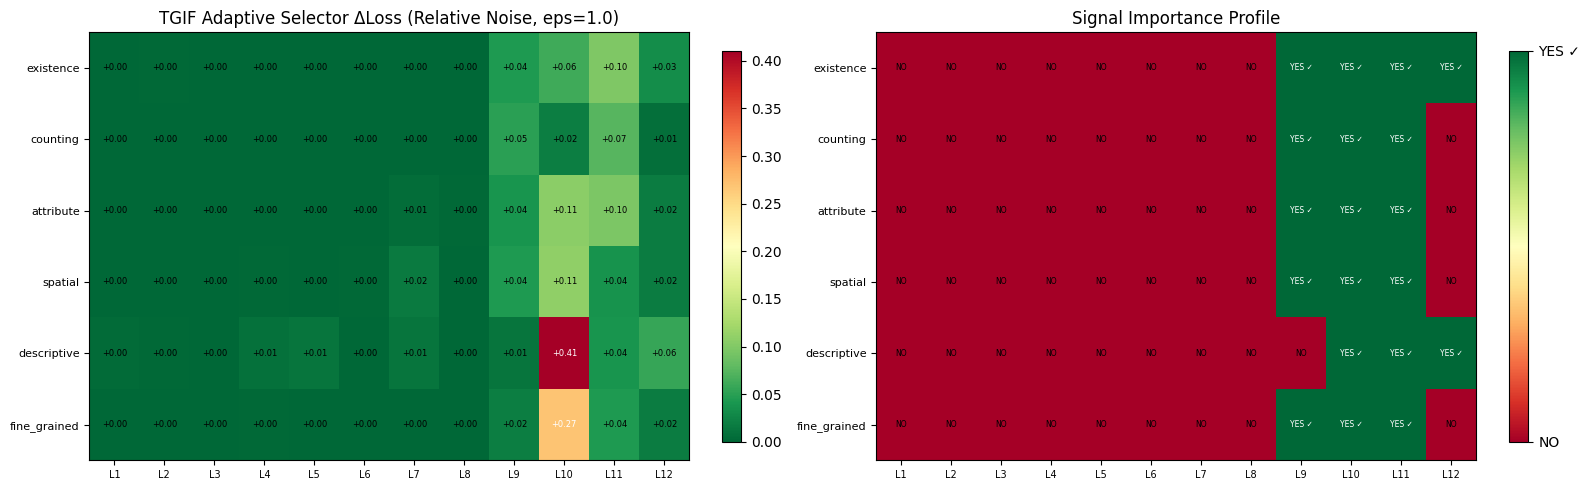

{'existence': {1: {1.0: [0.0008216500282287598,
    -0.00040084123611450195,
    0.001137465238571167,
    4.121661186218262e-05,
    0.0013977289199829102,
    0.00201338529586792,
    0.0005387067794799805,
    5.3048133850097656e-05,
    0.00043135881423950195,
    0.0004075765609741211,
    0.0005086958408355713,
    0.0015137791633605957,
    0.0021454691886901855,
    0.0035760104656219482,
    0.00042691826820373535,
    -0.00019550323486328125,
    -0.00023469328880310059,
    -0.0008757114410400391,
    0.0004379153251647949,
    0.0004731714725494385,
    0.00036454200744628906,
    -5.5670738220214844e-05,
    0.0005595684051513672,
    -0.0002783834934234619,
    5.0574541091918945e-05,
    0.0017600059509277344,
    0.007591545581817627,
    -0.0001575946807861328,
    0.0009161233901977539,
    0.0002492070198059082,
    0.0003438591957092285,
    0.0005225837230682373,
    0.00036907196044921875,
    0.0006389021873474121,
    2.849102020263672e-05,
    -0.00030195713043

In [ ]:
import re
import math
import string
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


CATEGORY_PROBES = {
    'existence'   : 'Is there a cricket bat visible in this image?',
    'counting'    : 'How many cricket bats are visible in this image?',
    'attribute'   : 'What color is the cricket ball in this image?',
    'spatial'     : 'Is the batsman on the left or right side of the image?',
    'descriptive' : 'Describe what is happening in this cricket image.',
    'fine_grained': 'Is the batsman in a defensive or attacking stance?',
}


# ============================================================
# ② TGIF ARCHITECTURE EVALUATION INTERFACE
# ============================================================
def eval_noise_injection_tgif_categories(model, tokenizer, category_probes,
                                        n_images=5, noise_levels=(1.0,),
                                        save_path=None):
    """
    Approach 3 (TGIF Architecture) — Noise Injection per Adaptive CLIP Layer.
    Isolates and evaluates the TGIF model's selective routing profiles using
    relative-scale noise constraints across layers L1 to L12.

    Updated to use rule-based category parsing strategy (Zero Cosine Similarities).
    """
    noise_levels = tuple(noise_levels)
    NUM_LAYERS = 12  # 12 CLIP layers (L1 to L12)

    model.eval()
    cat_names = list(category_probes.keys())

    # ── ① Category -> Rule-Based Keyword Mapping ──
    all_ids = sorted(instruct150k_images.keys())
    id_to_cat = {}
    for img_id in all_ids:
        qa = instruct150k_qa.get(img_id)
        if qa is None: continue
        _, qn_text, _ = qa
        if not qn_text: continue

        assigned_cat = get_category_by_rules(qn_text)

        if assigned_cat in cat_names:
            id_to_cat[img_id] = assigned_cat
        else:
            id_to_cat[img_id] = 'descriptive'

    cat_ids = {cat: [] for cat in cat_names}
    for img_id, cat in id_to_cat.items():
        cat_ids[cat].append(img_id)

    # ── Print Category Distribution Summary ──
    print(f'\n{"═"*60}')
    print(f'  RULE-BASED CATEGORY DISTRIBUTION SUMMARY (TGIF)')
    print(f'{"═"*60}')
    total_questions = sum(len(ids) for ids in cat_ids.values())
    for cat in cat_names:
        count = len(cat_ids[cat])
        percentage = (count / total_questions * 100) if total_questions > 0 else 0
        print(f'  • {cat:<15} : {count:>6} items ({percentage:>5.1f}%)')
    print(f'  {"─"*60}')
    print(f'  Total Dataset Size : {total_questions:>6} items')
    print(f'{"═"*60}\n')

    # ── ② Pure TGIF Autoregressive Loss Function ──
    def _fuse_loss_tgif(hidden, w_use, qn_toks, ans_toks):
        F_fused = sum(w_use[l] * hidden[l] for l in range(NUM_LAYERS))
        image_embed = model.proj_lin_layer(F_fused)
        image_embed = model.proj_model(image_embed)

        eoi_emb = model.llama.model.model.embed_tokens(eoi_tkn_tensor.unsqueeze(0))
        eoq_emb = model.llama.model.model.embed_tokens(eoq_tkn_tensor.unsqueeze(0))
        qn_emb = model.llama.model.model.embed_tokens(qn_toks)
        ans_emb = model.llama.model.model.embed_tokens(ans_toks)

        ctx = torch.cat([image_embed, eoi_emb, qn_emb, eoq_emb, ans_emb], dim=1)
        ctx = ctx.to(dtype=torch.float16)
        out = model.llama.forward(inputs_embeds=ctx)

        Q_ = qn_toks.shape[-1]; T_ = ans_toks.shape[-1]
        ans_start = 49 + eoi_tkn_tensor.shape[0] + Q_ + eoq_tkn_tensor.shape[0] - 1
        pred = out.logits[:, ans_start: ans_start + T_, :].float()
        if pred.shape[1] < T_: return None
        return F.cross_entropy(pred.reshape(T_, pred.shape[-1]), ans_toks.reshape(T_)).item()

    # ── ③ Processing Metric Arrays ──
    results_tgif = {cat: {l: {eps: [] for eps in noise_levels} for l in range(1, NUM_LAYERS + 1)} for cat in cat_names}
    results_tgif_noisy = {cat: {l: {eps: [] for eps in noise_levels} for l in range(1, NUM_LAYERS + 1)} for cat in cat_names}
    results_baseline_tgif = {cat: [] for cat in cat_names}

    print(f'{"═"*105}')
    print(f'  Approach 3 (TGIF Router) — Isolated Noise Injection Tracking Core Performance Matrix')
    print(f'{"═"*105}')

    for cat in cat_names:
        ids_for_cat = cat_ids[cat]
        if not ids_for_cat: continue

        rng = torch.Generator()
        rng.manual_seed(42 + cat_names.index(cat))
        perm = torch.randperm(len(ids_for_cat), generator=rng).tolist()
        sample_ids = [ids_for_cat[i] for i in perm[:n_images]]

        print(f'\n  ── Category: {cat} ──')

        with torch.no_grad():
            for img_id in sample_ids:
                qa = instruct150k_qa.get(img_id)
                if qa is None: continue
                _, qn_text, ans_text = qa
                if not qn_text or not ans_text: continue

                qn_toks = tokenizer(qn_text, return_tensors='pt', truncation=True, max_length=32)['input_ids'].to(device)
                ans_toks = tokenizer(ans_text, return_tensors='pt', truncation=True, max_length=16)['input_ids'].to(device)

                pil_img = get_image(img_id)
                inputs = model.clip_processor(images=pil_img, return_tensors='pt').to(device)
                clip_out = model.clip_model(**inputs, output_hidden_states=True)
                hidden_clean = [clip_out.hidden_states[l + 1][:, 1:, :].float() for l in range(NUM_LAYERS)]

                # Dynamic text embedding processing mapping target query vector to weights
                embeds = model.llama.model.model.embed_tokens(qn_toks)
                w_img = model.tgif_router(embeds.mean(dim=1)).squeeze(0)

                base_loss_tgif = _fuse_loss_tgif(hidden_clean, w_img, qn_toks, ans_toks)
                if base_loss_tgif is None: continue
                results_baseline_tgif[cat].append(base_loss_tgif)

                for l_hs in range(1, NUM_LAYERS + 1):  # Layers L1 to L12
                    for eps in noise_levels:
                        ht = [h.clone() for h in hidden_clean]

                        # Relative Noise Injection
                        layer_std = ht[l_hs - 1].std()
                        ht[l_hs - 1] = ht[l_hs - 1] + torch.randn_like(ht[l_hs - 1]) * (eps * layer_std)

                        lt = _fuse_loss_tgif(ht, w_img, qn_toks, ans_toks)
                        if lt is not None:
                            results_tgif[cat][l_hs][eps].append(lt - base_loss_tgif)
                            results_tgif_noisy[cat][l_hs][eps].append(lt)

        # ── ④ Synchronized Table Rendering ──
        bl_t_vals = results_baseline_tgif[cat]
        avg_bl_t = sum(bl_t_vals) / len(bl_t_vals) if bl_t_vals else float('nan')

        eps_hdrs = '  '.join(f'  eps={e:.1f}  new_loss   ΔLoss   Signal?' for e in noise_levels)
        sep_len = 30 + len(noise_levels) * 42
        print(f'  {"─" * sep_len}')
        print(f'  {"Layer":>5}  {"baseline_loss":>14}  {eps_hdrs}')
        print(f'  {"─" * sep_len}')
        for l in range(1, NUM_LAYERS + 1):
            line = f'  L{l:<4}  {avg_bl_t:>14.4f}'
            for eps in noise_levels:
                t_vals = results_tgif[cat][l][eps]
                n_vals = results_tgif_noisy[cat][l][eps]
                if not t_vals:
                    line += f'  {"N/A":>10}  {"N/A":>8}  {"N/A":>7}'
                else:
                    avg_tl = sum(t_vals) / len(t_vals)
                    avg_new_loss = sum(n_vals) / len(n_vals)
                    signal = 'YES ✓' if avg_bl_t <= avg_new_loss else 'NO   '
                    line += f'  {avg_new_loss:>10.4f}  {avg_tl:>+8.4f}  {signal}'
            print(line)
        print(f'  {"─" * sep_len}')

    # ── ⑤ Render Isolated TGIF Mapping Graphs ──
    n_eps = len(noise_levels)
    fig, axes = plt.subplots(n_eps, 2, figsize=(16, 4 * n_eps + 1))
    if n_eps == 1: axes = axes[np.newaxis, :]
    layer_labels = [f'L{l}' for l in range(1, NUM_LAYERS + 1)]

    for ei, eps in enumerate(noise_levels):
        tgif_mat = np.zeros((len(cat_names), NUM_LAYERS))
        signal_mat = np.zeros((len(cat_names), NUM_LAYERS))

        for ci, cat in enumerate(cat_names):
            bl_val = sum(results_baseline_tgif[cat]) / len(results_baseline_tgif[cat]) if results_baseline_tgif[cat] else 0.0
            for l_idx in range(1, NUM_LAYERS + 1):
                t = results_tgif[cat][l_idx][eps]
                n = results_tgif_noisy[cat][l_idx][eps]
                if t: tgif_mat[ci, l_idx - 1] = sum(t) / len(t)
                if n: signal_mat[ci, l_idx - 1] = 1.0 if bl_val <= sum(n)/len(n) else 0.0

        for ci, cat in enumerate(cat_names):
            for l_idx in range(1, NUM_LAYERS + 1):
                t = results_tgif[cat][l_idx][eps]
                n = results_tgif_noisy[cat][l_idx][eps]
                if t: tgif_mat[ci, l_idx - 1] = sum(t) / len(t)

                # Filter below significance threshold
                avg_delta = sum(t) / len(t) if t else 0.0
                if n: signal_mat[ci, l_idx - 1] = 1.0 if avg_delta > 0.02 else 0.0

        vt = max(float(tgif_mat.max()), 0.1)
        ax_h = axes[ei, 0]; im_h = ax_h.imshow(tgif_mat, cmap='RdYlGn_r', aspect='auto', vmin=0.0, vmax=vt)
        ax_h.set_xticks(range(NUM_LAYERS)); ax_h.set_xticklabels(layer_labels, fontsize=7)
        ax_h.set_yticks(range(len(cat_names))); ax_h.set_yticklabels(cat_names, fontsize=8)
        ax_h.set_title(f'TGIF Adaptive Selector ΔLoss (Relative Noise, eps={eps})')
        for ci in range(len(cat_names)):
            for l in range(NUM_LAYERS):
                v = tgif_mat[ci, l]
                ax_h.text(l, ci, f'{v:+.2f}', ha='center', va='center', fontsize=6, color='white' if abs(v) > vt * 0.6 else 'black')
        plt.colorbar(im_h, ax=ax_h, fraction=0.03)

        ax_s = axes[ei, 1]; im_s = ax_s.imshow(signal_mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax_s.set_xticks(range(NUM_LAYERS)); ax_s.set_xticklabels(layer_labels, fontsize=7)
        ax_s.set_yticks(range(len(cat_names))); ax_s.set_yticklabels(cat_names, fontsize=8)
        ax_s.set_title('Signal Importance Profile')
        for ci in range(len(cat_names)):
            for l in range(NUM_LAYERS):
                ax_s.text(l, ci, 'YES ✓' if signal_mat[ci, l] > 0.5 else 'NO', ha='center', va='center', fontsize=5.5, color='white' if signal_mat[ci, l] > 0.5 else 'black')
        plt.colorbar(im_s, ax=ax_s, fraction=0.03, ticks=[0, 1]).ax.set_yticklabels(['NO', 'YES ✓'])

    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    model.train()
    return results_tgif

# ============================================================
# ③ EXECUTION
# ============================================================
eval_noise_injection_tgif_categories(
    phi2_proj_model, tokenizer, CATEGORY_PROBES,
    n_images=460,
    noise_levels=(1.0,),
    save_path='approach3_tgif_noise_injection.png'
)

# **Experiment 1 : Static Dense Connector vs. Dynamic TGIF Under Layer Dropout**


════════════════════════════════════════════════════════════
  RULE-BASED CATEGORY DISTRIBUTION SUMMARY (TGIF DROPOUT)
════════════════════════════════════════════════════════════
  • existence       :     43 items (  9.2%)
  • counting        :    216 items ( 46.2%)
  • attribute       :     44 items (  9.4%)
  • spatial         :     71 items ( 15.2%)
  • descriptive     :     58 items ( 12.4%)
  • fine_grained    :     36 items (  7.7%)
  ────────────────────────────────────────────────────────────
  Total Dataset Size :    468 items
════════════════════════════════════════════════════════════

  Processing Layer Drops for Category: existence...
  Processing Layer Drops for Category: counting...
  Processing Layer Drops for Category: attribute...
  Processing Layer Drops for Category: spatial...
  Processing Layer Drops for Category: descriptive...
  Processing Layer Drops for Category: fine_grained...


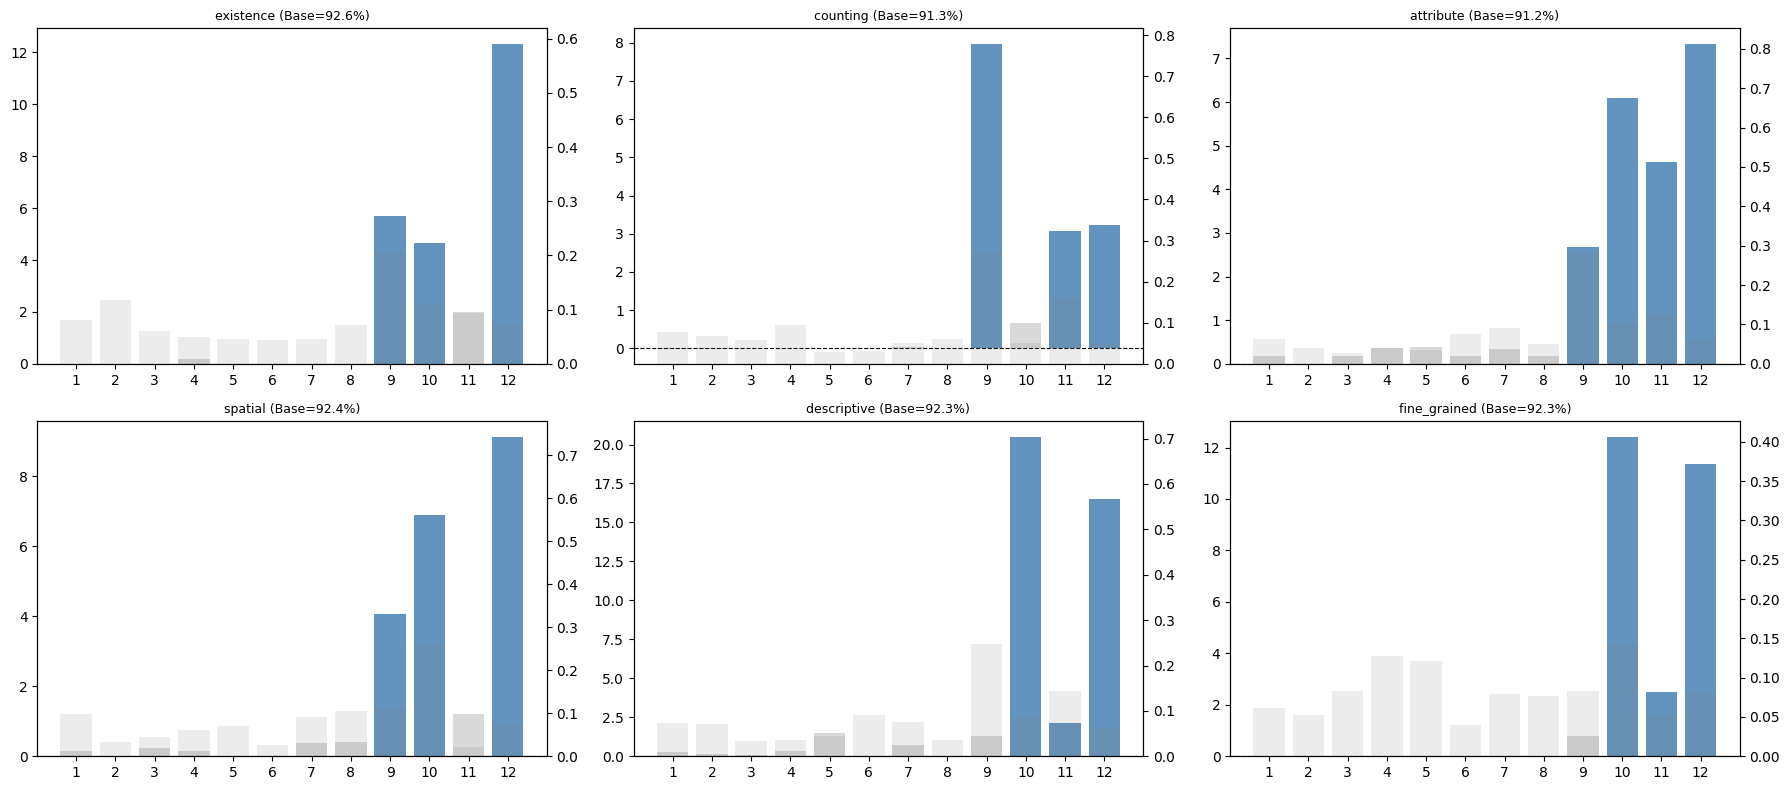

In [ ]:
import re
import math
import string
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ============================================================
# ② TGIF DROPOUT ABLATION ENGINE WITH RULES INTEGRATED
# ============================================================
def eval_layer_dropout_accuracy_tgif_new(model, tokenizer, category_probes,
                                     n_images=5, save_path=None):
    """
    Approach 2 — Layer Dropout Answer Token-Accuracy Ablation (TGIF).
    Ablates layers sequentially by masking weights and computes accuracy drops
    using properly aligned causal fusion mechanisms.

    Updated: Uses rule-based keyword matching strategies for flawless data partitioning.
    """
    NUM_LAYERS = 12  # 12 CLIP layers (L1 to L12)
    model.eval()
    cat_names = list(category_probes.keys())

    # Dynamic unwrapper loops to extract the leaf embedding layer regardless of PEFT depth
    base_llm = model.llama
    while hasattr(base_llm, "model"):
        base_llm = base_llm.model
    embed_tokens_layer = base_llm.embed_tokens

    # ── ① Category -> Rule-Based Keyword Mapping (Zero Embeddings Used Here) ──
    all_ids = sorted(instruct150k_images.keys())
    id_to_cat = {}
    for img_id in all_ids:
        qa = instruct150k_qa.get(img_id)
        if qa is None: continue
        _, qn_text, _ = qa
        if not qn_text: continue

        assigned_cat = get_category_by_rules(qn_text)

        if assigned_cat in cat_names:
            id_to_cat[img_id] = assigned_cat
        else:
            id_to_cat[img_id] = 'descriptive'

    cat_ids = {cat: [] for cat in cat_names}
    for img_id, cat in id_to_cat.items():
        cat_ids[cat].append(img_id)

    # ── Print Category Distribution Summary ──
    print(f'\n{"═"*60}')
    print(f'  RULE-BASED CATEGORY DISTRIBUTION SUMMARY (TGIF DROPOUT)')
    print(f'{"═"*60}')
    total_questions = sum(len(ids) for ids in cat_ids.values())
    for cat in cat_names:
        count = len(cat_ids[cat])
        percentage = (count / total_questions * 100) if total_questions > 0 else 0
        print(f'  • {cat:<15} : {count:>6} items ({percentage:>5.1f}%)')
    print(f'  {"─"*60}')
    print(f'  Total Dataset Size : {total_questions:>6} items')
    print(f'{"═"*60}\n')

    # Get baseline reference weights for the visualization reference profiles
    with torch.no_grad():
        cat_router_wts = {}
        for cat, probe in category_probes.items():
            toks = tokenizer(probe, return_tensors='pt', truncation=True, max_length=32)['input_ids'].to(device)
            embeds = embed_tokens_layer(toks)
            cat_router_wts[cat] = model.tgif_router(embeds.mean(dim=1)).squeeze(0).cpu()

    # ── ② Causal Token Accuracy Engine ──
    def _fuse_and_token_acc(hidden, w_use, qn_toks, ans_toks):
        layer_hs = torch.stack(hidden, dim=1)
        weights_tensor = w_use.unsqueeze(0) if w_use.dim() == 1 else w_use

        # Linear projection and cross-attention layer calculation via native fuser
        F_fused = tgif_fuse_layers(layer_hs, weights_tensor)

        image_embed = model.proj_lin_layer(F_fused)
        image_embed = model.proj_model(image_embed)

        eoi_emb = embed_tokens_layer(eoi_tkn_tensor.unsqueeze(0))
        eoq_emb = embed_tokens_layer(eoq_tkn_tensor.unsqueeze(0))
        qn_emb = embed_tokens_layer(qn_toks)
        ans_emb = embed_tokens_layer(ans_toks)

        ctx = torch.cat([image_embed, eoi_emb, qn_emb, eoq_emb, ans_emb], dim=1)
        ctx = ctx.to(dtype=torch.float16)
        out = model.llama.forward(inputs_embeds=ctx)

        Q_ = qn_toks.shape[-1]; T_ = ans_toks.shape[-1]

        # Extract target predictions using causal shift rules
        ans_start = 49 + eoi_tkn_tensor.shape[0] + Q_ + eoq_tkn_tensor.shape[0]
        pred = out.logits[:, ans_start - 1 : ans_start + T_ - 1, :].float()

        if pred.shape[1] < T_: return None
        pred_ids = pred.squeeze(0).argmax(dim=-1)
        gt_ids = ans_toks.squeeze(0)
        return (pred_ids == gt_ids).float().mean().item()

    # ── ③ Ablation Execution Loop ──
    all_delta_acc = {}; all_base_acc = {}

    for cat in cat_names:
        ids_for_cat = cat_ids[cat]
        if not ids_for_cat: continue

        rng = torch.Generator(); rng.manual_seed(42 + cat_names.index(cat))
        sample_ids = [ids_for_cat[i] for i in torch.randperm(len(ids_for_cat), generator=rng).tolist()[:n_images]]

        base_accs = []; ablated_accs = [[] for _ in range(NUM_LAYERS)]; per_img_wts = []

        print(f'  Processing Layer Drops for Category: {cat}...')

        with torch.no_grad():
            for img_id in sample_ids:
                qa = instruct150k_qa.get(img_id)
                if qa is None: continue
                _, qn_text, ans_text = qa
                qn_toks = tokenizer(qn_text, return_tensors='pt', truncation=True, max_length=32)['input_ids'].to(device)
                ans_toks = tokenizer(ans_text, return_tensors='pt', truncation=True, max_length=16)['input_ids'].to(device)

                pil_img = get_image(img_id)
                inputs = model.clip_processor(images=pil_img, return_tensors='pt').to(device)
                clip_out = model.clip_model(**inputs, output_hidden_states=True)
                hidden = [clip_out.hidden_states[l + 1][:, 1:, :].float() for l in range(NUM_LAYERS)]

                embeds = embed_tokens_layer(qn_toks)
                w = model.tgif_router(embeds.mean(dim=1)).squeeze(0)
                per_img_wts.append(w.cpu())

                base = _fuse_and_token_acc(hidden, w, qn_toks, ans_toks)
                if base is None: continue
                base_accs.append(base)

                for l_abl in range(NUM_LAYERS):
                    w_abl = w.clone(); w_abl[l_abl] = 0.0
                    if (rem := w_abl.sum()) > 1e-9: w_abl = w_abl / rem
                    acc_abl = _fuse_and_token_acc(hidden, w_abl, qn_toks, ans_toks)
                    if acc_abl is not None: ablated_accs[l_abl].append(acc_abl)

        baseline = sum(base_accs) / max(len(base_accs), 1)
        delta_means = [baseline - (sum(ablated_accs[l]) / max(len(ablated_accs[l]), 1)) for l in range(NUM_LAYERS)]
        all_delta_acc[cat] = delta_means; all_base_acc[cat] = baseline

    # ── ④ Subplot Generation ──
    fig, axes = plt.subplots((len(cat_names)+2)//3, 3, figsize=(18, 4 * ((len(cat_names)+2)//3)))
    axes_flat = axes.flatten(); layer_ids = list(range(1, NUM_LAYERS + 1))

    for idx, cat in enumerate(cat_names):
        ax = axes_flat[idx]; d_arr = np.array(all_delta_acc.get(cat, [0]*NUM_LAYERS)) * 100
        w_arr = cat_router_wts[cat].numpy()

        ax2 = ax.twinx(); ax2.bar(layer_ids, w_arr, alpha=0.15, color='grey')
        ax2.set_ylim(0, max(w_arr.max() * 3, 0.4))

        colors = ['tomato' if d < -2 else ('steelblue' if d > 2 else 'lightgrey') for d in d_arr]
        ax.bar(layer_ids, d_arr, color=colors, alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f'{cat} (Base={all_base_acc.get(cat, 0)*100:.1f}%)', fontsize=9)
        ax.set_xticks(layer_ids)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    model.train()

# ============================================================
# ③ EXECUTION RUN
# ============================================================
eval_layer_dropout_accuracy_tgif_new(phi2_proj_model, tokenizer, CATEGORY_PROBES, n_images=460)

# **End**